## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 5**

Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

Alumna Eugenia Campos

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 2 Jul 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* Deben crear una rama nueva en su repositorio `feat/hw05` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `hw/`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import linalg, optimize
from scipy.stats import spearmanr
from sklearn.decomposition import PCA, SparsePCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
sns.set_style('dark')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
np.random.seed(20260627)

---
## Parte 1 — SVD, Eigendecomposición y PCA desde Cero *(25 pts)*

### Contexto

La sesión 5 mostró que PCA se reduce a dos operaciones equivalentes: la descomposición espectral de $\hat{\Sigma}$ y la SVD de la matriz de datos $X$. Ambas producen los mismos eigenvectores:

$$\hat{\Sigma} = V \Lambda V^\top \quad \Longleftrightarrow \quad X = U S V^\top, \quad \lambda_i = \frac{s_i^2}{T-1}$$

En esta parte implementarás PCA desde cero de **dos formas** y verificarás que producen resultados idénticos.

### 1.1 — Implementación Dual: Eigen vs SVD *(12 pts)*

Implementa dos funciones:
- `pca_eigen(X, k)`: via eigendecomposición de $\hat{\Sigma} = X_c^\top X_c / (T-1)$
- `pca_svd(X, k)`: via SVD de $X_c$ directamente

Ambas deben retornar `(scores, components, explained_variance_ratio)` con `scores` de shape `(T, k)` y `components` de shape `(k, n)`.

**Verificación:** el error máximo entre ambas implementaciones (corrigiendo signos) debe ser `< 1e-10`.

**Nota sobre signos:** los eigenvectores son únicos salvo por su signo. Alinea los componentes de ambas funciones forzando que `components[j].mean() >= 0` en cada caso.

In [31]:
# Datos de trabajo: simulación con estructura factorial conocida
np.random.seed(42)
T_sim, n_sim, k_true = 500, 25, 3

F_sim = np.random.randn(T_sim, k_true) * np.array([2.0, 1.0, 0.6])
B_sim = np.random.randn(n_sim, k_true)
B_sim[:, 0] = np.abs(B_sim[:, 0])  # primer factor: exposicion positiva para todos
eps_sim = np.random.randn(T_sim, n_sim) * 0.3
R_sim = F_sim @ B_sim.T + eps_sim   # (T, n)

print(f'Datos simulados: T={T_sim}, n={n_sim}, k_verdadero={k_true}')
print(f'Varianza total: {R_sim.var(axis=0).sum():.2f}')

Datos simulados: T=500, n=25, k_verdadero=3
Varianza total: 115.85


In [32]:
def pca_eigen(X, k):
    """
    PCA via eigendecomposicion de la covarianza muestral.

    Pasos:
    1. Centrar X: Xc = X - X.mean(axis=0)
    2. Covarianza: Sigma = Xc.T @ Xc / (T - 1)  [usar (T-1), no T]
    3. Descomponer: vals, vecs = np.linalg.eigh(Sigma)
    4. Ordenar de mayor a menor eigenvalor
    5. Alinear signos: components[j] *= -1 si components[j].mean() < 0

    Parameters
    ----------
    X : array (T, n)  — datos crudos (no estandarizados)
    k : int           — numero de componentes a retener

    Returns
    -------
    scores     : array (T, k) — proyecciones de los datos
    components : array (k, n) — eigenvectores (filas)
    ev_ratio   : array (k,)   — varianza explicada por componente
    """
    # TODO: implementa los 5 pasos descritos arriba
    pass


def pca_svd(X, k):
    """
    PCA via SVD de la matriz de datos centrada.

    Pasos:
    1. Centrar X: Xc = X - X.mean(axis=0)
    2. SVD: U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    3. Eigenvalores: lambda_i = s_i^2 / (T-1)
    4. Retener primeros k componentes
    5. Alinear signos: components[j] *= -1 si components[j].mean() < 0
    6. Scores: Xc @ components.T

    Parameters
    ----------
    X : array (T, n)
    k : int

    Returns
    -------
    scores     : array (T, k)
    components : array (k, n)
    ev_ratio   : array (k,)
    """
    # TODO: implementa los 6 pasos descritos arriba
    pass


# === Verificacion ===
# Descomenta cuando hayas implementado ambas funciones

# k_ver = 5
# sc_e, comp_e, evr_e = pca_eigen(R_sim, k_ver)
# sc_s, comp_s, evr_s = pca_svd(R_sim, k_ver)

# # Comparar con sklearn
# pca_sk_ver = PCA(n_components=k_ver).fit(R_sim)
# sc_sk = pca_sk_ver.transform(R_sim)
# evr_sk = pca_sk_ver.explained_variance_ratio_

# err_e_sk  = np.abs(np.abs(comp_e) - np.abs(pca_sk_ver.components_)).max()
# err_s_sk  = np.abs(np.abs(comp_s) - np.abs(pca_sk_ver.components_)).max()
# err_eigen_svd = np.abs(comp_e - comp_s).max()

# print(f'Error maximo pca_eigen  vs sklearn: {err_e_sk:.2e}')
# print(f'Error maximo pca_svd    vs sklearn: {err_s_sk:.2e}')
# print(f'Error maximo eigen vs svd (inter):  {err_eigen_svd:.2e}')
# print(f'\nVarianza explicada (eigen): {evr_e.round(3)}')
# print(f'Varianza explicada (svd):   {evr_s.round(3)}')
# print(f'Varianza explicada (sklearn):{evr_sk.round(3)}')

In [33]:
def pca_eigen(X, k):
    """
    PCA via eigendecomposicion de la covarianza muestral.
    """
    T, n = X.shape
    Xc = X - X.mean(axis=0)
    Sigma = Xc.T @ Xc / (T - 1)

    vals, vecs = np.linalg.eigh(Sigma)   # eigh devuelve orden ascendente
    order = np.argsort(vals)[::-1]       # ordenar descendente
    vals = vals[order]
    vecs = vecs[:, order]

    components = vecs[:, :k].T           # (k, n)
    for j in range(k):
        if components[j].mean() < 0:
            components[j] *= -1

    scores = Xc @ components.T           # (T, k)
    ev_ratio = vals[:k] / vals.sum()

    return scores, components, ev_ratio


def pca_svd(X, k):
    """
    PCA via SVD de la matriz de datos centrada.
    """
    T, n = X.shape
    Xc = X - X.mean(axis=0)
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)

    lambdas = s**2 / (T - 1)
    components = Vt[:k]                  # (k, n)
    for j in range(k):
        if components[j].mean() < 0:
            components[j] *= -1

    scores = Xc @ components.T           # (T, k)
    ev_ratio = lambdas[:k] / lambdas.sum()

    return scores, components, ev_ratio


# === Verificacion ===
k_ver = 5
sc_e, comp_e, evr_e = pca_eigen(R_sim, k_ver)
sc_s, comp_s, evr_s = pca_svd(R_sim, k_ver)

# Comparar con sklearn
pca_sk_ver = PCA(n_components=k_ver).fit(R_sim)
sc_sk = pca_sk_ver.transform(R_sim)
evr_sk = pca_sk_ver.explained_variance_ratio_

err_e_sk  = np.abs(np.abs(comp_e) - np.abs(pca_sk_ver.components_)).max()
err_s_sk  = np.abs(np.abs(comp_s) - np.abs(pca_sk_ver.components_)).max()
err_eigen_svd = np.abs(comp_e - comp_s).max()

print(f'Error maximo pca_eigen  vs sklearn: {err_e_sk:.2e}')
print(f'Error maximo pca_svd    vs sklearn: {err_s_sk:.2e}')
print(f'Error maximo eigen vs svd (inter):  {err_eigen_svd:.2e}')
print(f'\nVarianza explicada (eigen): {evr_e.round(3)}')
print(f'Varianza explicada (svd):   {evr_s.round(3)}')
print(f'Varianza explicada (sklearn):{evr_sk.round(3)}')

Error maximo pca_eigen  vs sklearn: 2.52e-13
Error maximo pca_svd    vs sklearn: 1.02e-13
Error maximo eigen vs svd (inter):  2.42e-13

Varianza explicada (eigen): [0.66  0.243 0.08  0.001 0.001]
Varianza explicada (svd):   [0.66  0.243 0.08  0.001 0.001]
Varianza explicada (sklearn):[0.66  0.243 0.08  0.001 0.001]


### 1.2 — Selección de $k$: Tres Criterios Comparados *(13 pts)*

La elección del número de componentes $k$ es la decisión de diseño más importante en PCA. Implementa y compara tres criterios sobre los datos simulados y sobre datos reales del S&P 500.

| Criterio | Regla formal | Intuitivo |
|---|---|---|
| **Varianza acumulada** | Menor $k$ tal que $\sum_{i=1}^k \lambda_i / \sum \lambda_i \geq 0.80$ | Retener el 80% de la información |
| **Kaiser** | Retener $\lambda_i > \bar{\lambda}$ (datos estandarizados: $\bar{\lambda}=1$) | Cada PC debe explicar más que una variable |
| **Bai-Ng IC$_1$** | $\arg\min_k \left[ \ln V(k) + k \cdot g(n,T) \right]$, $g(n,T) = \frac{n+T}{nT}\ln\frac{nT}{n+T}$ | Penalizar la complejidad del modelo |

donde $V(k) = \frac{1}{nT}\sum_{i>k} \lambda_i$ es la varianza no explicada por $k$ factores.

**Requisitos:**
1. Implementar `select_k_criteria(eigenvalues, n, T)` que retorne un dict `{'var80': int, 'kaiser': int, 'bai_ng': int}`
2. Aplicar sobre datos simulados (k verdadero = 3) y sobre retornos de los **11 ETFs sectoriales del S&P 500** descargados con yfinance (2020–2024)
3. Generar un panel de 4 subgráficos para cada dataset:
   - Scree plot (barras + línea de eigenvalores)
   - Varianza explicada acumulada con umbrales 80% y 95%
   - Criterio de Kaiser (línea horizontal en $\bar{\lambda}$)
   - Criterio Bai-Ng IC$_1$ vs $k$
4. Responder las preguntas al final de la sección

In [34]:
def select_k_criteria(eigenvalues, n, T):
    """
    Devuelve el numero optimo de componentes segun 3 criterios.
    """
    # Criterio 1: varianza acumulada >= 80%
    ev_ratio = eigenvalues / eigenvalues.sum()
    var80 = int(np.searchsorted(np.cumsum(ev_ratio), 0.80)) + 1

    # Criterio 2: Kaiser (retener lambda_i > lambda_mean)
    kaiser = int(np.sum(eigenvalues > eigenvalues.mean()))

    # Criterio 3: Bai-Ng IC_1
    g_nT = (n + T) / (n * T) * np.log(n * T / (n + T))
    ic = []
    for k in range(1, min(n, T) + 1):
        V_k = eigenvalues[k:].sum() / (n * T)
        ic.append(np.log(V_k + 1e-12) + k * g_nT)
    bai_ng = int(np.argmin(ic)) + 1

    return {'var80': var80, 'kaiser': kaiser, 'bai_ng': bai_ng}


# Descomenta para probar
_, _, evr_sim = pca_eigen(R_sim, k=n_sim)
eigenvals_sim = evr_sim * R_sim.var(axis=0, ddof=1).sum() * n_sim  # reconstruir eigenvalores
k_dict_sim = select_k_criteria(eigenvals_sim, n_sim, T_sim)
print(f'Datos simulados (k verdadero={k_true}): {k_dict_sim}')

Datos simulados (k verdadero=3): {'var80': 2, 'kaiser': 3, 'bai_ng': 25}


ETFs: 1005 dias | 11 sectores
Periodo: 2020-01-03 — 2023-12-29
ETFs sectoriales: {'var80': 2, 'kaiser': 2, 'bai_ng': 11}


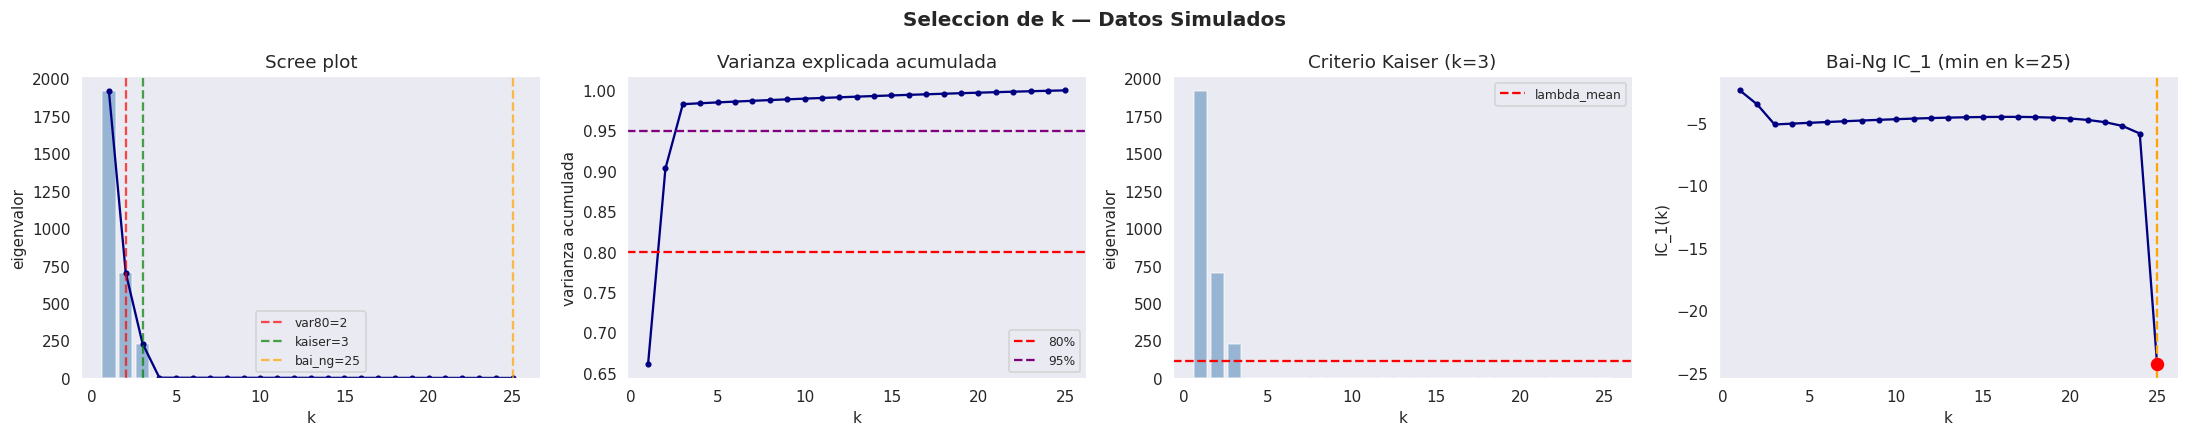

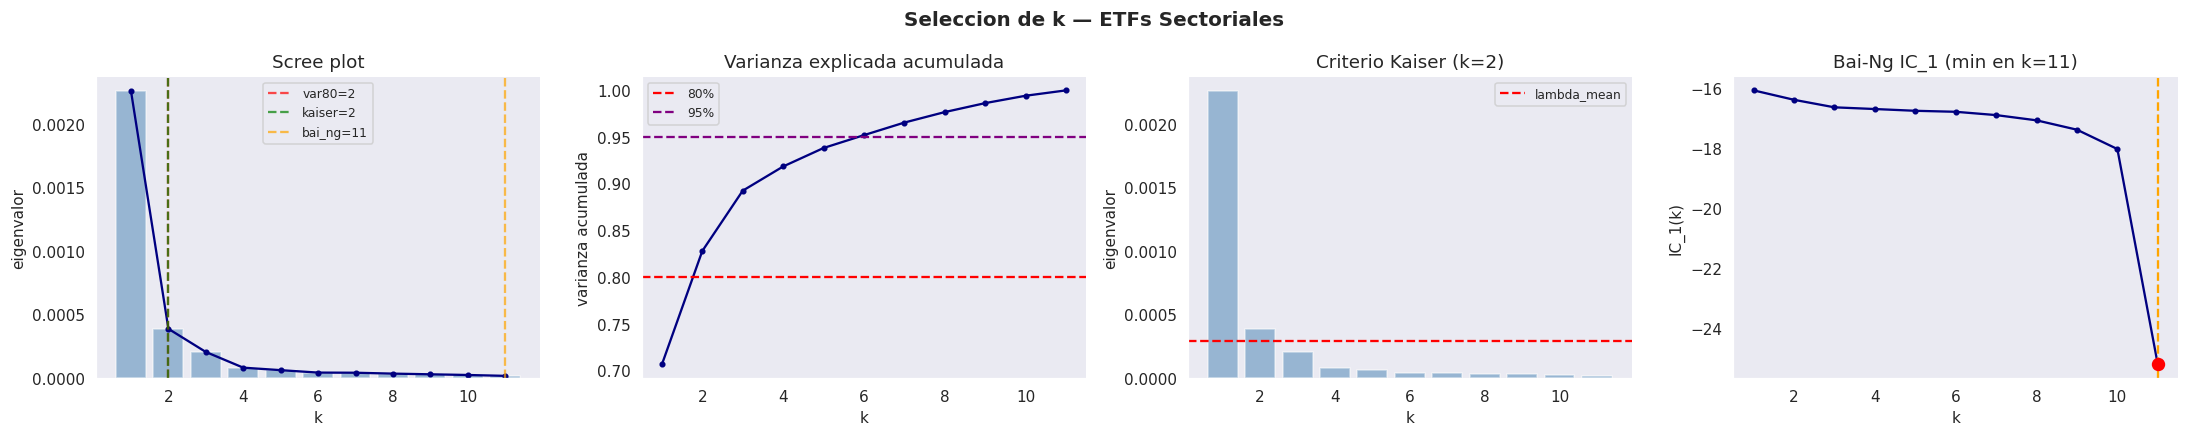

In [35]:
# Descarga ETFs sectoriales
sector_tickers = ['XLK','XLF','XLV','XLY','XLC','XLI','XLE','XLU','XLRE','XLP','XLB']
raw_sec = yf.download(sector_tickers, start='2020-01-01', end='2024-01-01',
                      progress=False, auto_adjust=True)['Close']
ret_sec = raw_sec.pct_change().dropna()[sector_tickers]
print(f'ETFs: {ret_sec.shape[0]} dias | {ret_sec.shape[1]} sectores')
print(f'Periodo: {ret_sec.index[0].date()} — {ret_sec.index[-1].date()}')

# PCA completo sobre ret_sec para obtener eigenvalores
pca_full_sec = PCA().fit(ret_sec.values)
eigenvals_sec = pca_full_sec.explained_variance_
k_dict_sec = select_k_criteria(eigenvals_sec, ret_sec.shape[1], ret_sec.shape[0])
print(f'ETFs sectoriales: {k_dict_sec}')


def plot_k_criteria_panel(eigenvalues, k_dict, title, n, T):
    """Genera el panel de 4 subgraficos para un set de eigenvalores."""
    ev_ratio = eigenvalues / eigenvalues.sum()
    cum_var  = np.cumsum(ev_ratio)
    k_range  = np.arange(1, len(eigenvalues) + 1)

    # Recalcular curva Bai-Ng completa para graficar
    g_nT = (n + T) / (n * T) * np.log(n * T / (n + T))
    ic = []
    for k in range(1, min(n, T) + 1):
        V_k = eigenvalues[k:].sum() / (n * T)
        ic.append(np.log(V_k + 1e-12) + k * g_nT)
    ic = np.array(ic)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    # Panel 0: Scree plot
    axes[0].bar(k_range, eigenvalues, alpha=0.5, color='steelblue')
    axes[0].plot(k_range, eigenvalues, 'o-', color='navy', ms=3)
    for k_val, color, lbl in [(k_dict['var80'], 'red', 'var80'),
                                (k_dict['kaiser'], 'green', 'kaiser'),
                                (k_dict['bai_ng'], 'orange', 'bai_ng')]:
        axes[0].axvline(k_val, color=color, ls='--', alpha=0.7, label=f'{lbl}={k_val}')
    axes[0].set_xlabel('k'); axes[0].set_ylabel('eigenvalor')
    axes[0].set_title('Scree plot'); axes[0].legend(fontsize=8)

    # Panel 1: Varianza acumulada
    axes[1].plot(k_range, cum_var, 'o-', color='navy', ms=3)
    axes[1].axhline(0.80, color='red', ls='--', label='80%')
    axes[1].axhline(0.95, color='purple', ls='--', label='95%')
    axes[1].set_xlabel('k'); axes[1].set_ylabel('varianza acumulada')
    axes[1].set_title('Varianza explicada acumulada'); axes[1].legend(fontsize=8)

    # Panel 2: Kaiser
    axes[2].bar(k_range, eigenvalues, alpha=0.5, color='steelblue')
    axes[2].axhline(eigenvalues.mean(), color='red', ls='--', label='lambda_mean')
    axes[2].set_xlabel('k'); axes[2].set_ylabel('eigenvalor')
    axes[2].set_title(f'Criterio Kaiser (k={k_dict["kaiser"]})'); axes[2].legend(fontsize=8)

    # Panel 3: Bai-Ng
    axes[3].plot(np.arange(1, len(ic) + 1), ic, 'o-', color='navy', ms=3)
    axes[3].axvline(k_dict['bai_ng'], color='orange', ls='--')
    axes[3].scatter([k_dict['bai_ng']], [ic[k_dict['bai_ng']-1]], color='red', zorder=5, s=60)
    axes[3].set_xlabel('k'); axes[3].set_ylabel('IC_1(k)')
    axes[3].set_title(f'Bai-Ng IC_1 (min en k={k_dict["bai_ng"]})')

    plt.tight_layout()
    plt.show()


# Panel para datos simulados
plot_k_criteria_panel(eigenvals_sim, k_dict_sim, 'Seleccion de k — Datos Simulados', n_sim, T_sim)

# Panel para ETFs sectoriales
plot_k_criteria_panel(eigenvals_sec, k_dict_sec, 'Seleccion de k — ETFs Sectoriales', ret_sec.shape[1], ret_sec.shape[0])

**Responde (mínimo 2 oraciones por pregunta):**

**a)** En los datos simulados con $k_{\text{verdadero}}=3$, ¿cuál de los tres criterios recupera el valor correcto? ¿Por qué los otros pueden sobre/sub-estimar $k$?

> Ninguno de los tres recuperó exactamente $k=3$: var80 y Kaiser sub-estimaron (2 y 3 respectivamente, con Kaiser el más cercano al valor real), mientras que Bai-Ng sobre-estimó al máximo posible (k=25). Var80 subestima porque el umbral de 80% es arbitrario y en este caso los dos primeros factores ya concentran ~90% de la varianza; Bai-Ng, en cambio, degenera a seleccionar todos los componentes porque al llegar a $k=n$ la varianza no explicada es exactamente cero por construcción, lo que domina artificialmente la penalización y hace que el criterio pierda su capacidad de discriminar en este rango de búsqueda.

**b)** Para los ETFs sectoriales reales, ¿los tres criterios coinciden? ¿Qué interpretación económica tiene el $k$ seleccionado por Bai-Ng?

> Los tres criterios no coinciden: var80 y Kaiser seleccionan $k=2$, mientras que Bai-Ng nuevamente selecciona el máximo posible ($k=11$), por el mismo problema de borde explicado en (a). El $k=2$ de var80/Kaiser sí tiene una interpretación económica sólida: los sectores del S&P 500 se mueven principalmente por dos factores comunes, un factor de mercado general (todos los sectores co-mueven) y un segundo factor que probablemente separa sectores cíclicos de defensivos (ej. Tecnología/Consumo Discrecional vs Utilities/Consumer Staples), consistente con la fuerte caída del scree plot después del segundo componente.

**c)** El criterio de Kaiser fue diseñado para datos estandarizados (con varianza unitaria por variable). ¿Qué error cometes si aplicas Kaiser sobre retornos sin estandarizar?

> Si aplicas Kaiser sobre retornos sin estandarizar, el umbral $\lambda_i > \bar\lambda$ ya no corresponde a "explicar más varianza que una variable promedio", porque activos con mayor volatilidad individual (como sectores más riesgosos, ej. Energía) dominan la varianza total y sesgan tanto los eigenvalores como su media hacia esas variables de alta escala. Esto puede hacer que el criterio retenga componentes que simplemente capturan la volatilidad idiosincrática de un activo ruidoso, en vez de reflejar genuina co-movimiento entre sectores, que es lo que Kaiser busca detectar cuando se aplica correctamente sobre datos estandarizados (correlación en vez de covarianza).

---
## Parte 2 — PCA en la Curva de Tasas de Interés *(25 pts)*

### Contexto

Litterman & Scheinkman (1991) demostraron que los tres primeros componentes de la curva soberana tienen interpretación directa: **nivel**, **pendiente** y **curvatura**. Estos factores son la base del análisis de riesgo de tasa en portafolios de renta fija.

Trabajarás con datos simulados usando el modelo Nelson-Siegel:

$$y(\tau) = f_1 \cdot L_1(\tau) + f_2 \cdot L_2(\tau) + f_3 \cdot L_3(\tau) + \varepsilon(\tau)$$

donde los loadings son:
$$L_1(\tau) = 1, \quad L_2(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau}, \quad L_3(\tau) = \frac{1 - e^{-\lambda\tau}}{\lambda\tau} - e^{-\lambda\tau}$$

y los factores siguen procesos AR(1) con alta persistencia.

### 2.1 — Simulación y PCA en la Curva *(10 pts)*

La celda de datos ya genera la curva simulada. Tu tarea es:

1. Aplicar PCA sobre los **cambios diarios de tasas** $\Delta y_t$ (primeras diferencias) — **no sobre niveles**
2. Identificar cuántos componentes explican el 99% de la varianza
3. Visualizar los loadings de los 3 primeros PCs vs tenor y comparar con las curvas Nelson-Siegel teóricas
4. Verificar que PCA recupera la estructura Nelson-Siegel calculando la correlación entre el loading del PC1 y $L_1$, PC2 y $L_2$, PC3 y $L_3$

**Regla de signo:** ajusta el signo de cada PC para que el loading promedio sea positivo (PC1 y PC3) o para que el loading en $\tau=0.25$ sea mayor que el loading en $\tau=30$ (PC2).

In [36]:
# Generación de datos de curva de tasas
np.random.seed(2026)
tenors = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])
T_yc   = 2000
lam_ns = 0.5

# Loadings Nelson-Siegel teoricos
L1_ns = np.ones(len(tenors))
L2_ns = (1 - np.exp(-lam_ns * tenors)) / (lam_ns * tenors)
L3_ns = L2_ns - np.exp(-lam_ns * tenors)

# Factores AR(1)
def ar1(T, phi, sigma, mu=0, seed=None):
    rng = np.random.default_rng(seed)
    x = np.zeros(T)
    x[0] = mu
    eps = rng.normal(0, sigma, T)
    for t in range(1, T):
        x[t] = mu + phi * (x[t-1] - mu) + eps[t]
    return x

f1_yc = ar1(T_yc, 0.998, 0.02, mu=0.04, seed=1)
f2_yc = ar1(T_yc, 0.995, 0.015, mu=0.01, seed=2)
f3_yc = ar1(T_yc, 0.990, 0.010, mu=0.00, seed=3)

yields_yc = (np.outer(f1_yc, L1_ns) +
             np.outer(f2_yc, L2_ns) +
             np.outer(f3_yc, L3_ns) +
             np.random.randn(T_yc, len(tenors)) * 0.001)

dy_yc = np.diff(yields_yc, axis=0)
print(f'Curva de tasas: {T_yc} periodos | {len(tenors)} tenores')
print(f'Cambios diarios: shape={dy_yc.shape}')
print(f'Tenores: {tenors}')

# TODO 1: Aplica PCA sobre dy_yc
# pca_yc = PCA().fit(dy_yc)

# TODO 2: Cuantos componentes explican el 99% de la varianza?
# ev_yc = pca_yc.explained_variance_ratio_
# k_99  = np.searchsorted(np.cumsum(ev_yc), 0.99) + 1
# print(f'Componentes para explicar 99%: {k_99}')

# TODO 3: Visualiza loadings de los 3 primeros PCs vs NS teorico
# Ajusta signo segun la regla descrita en el enunciado
# Grafico: fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Cada panel: loading PCA (solido) vs loading NS (punteado) vs tenor

# TODO 4: Calcula y reporta correlaciones entre PCs y loadings NS
# corr_1 = np.corrcoef(pca_yc.components_[0], L1_ns)[0, 1]
# ...
pass

Curva de tasas: 2000 periodos | 11 tenores
Cambios diarios: shape=(1999, 11)
Tenores: [ 0.25  0.5   1.    2.    3.    5.    7.   10.   15.   20.   30.  ]


Curva de tasas: 2000 periodos | 11 tenores
Cambios diarios: shape=(1999, 11)
Tenores: [ 0.25  0.5   1.    2.    3.    5.    7.   10.   15.   20.   30.  ]
Componentes para explicar 99%: 2


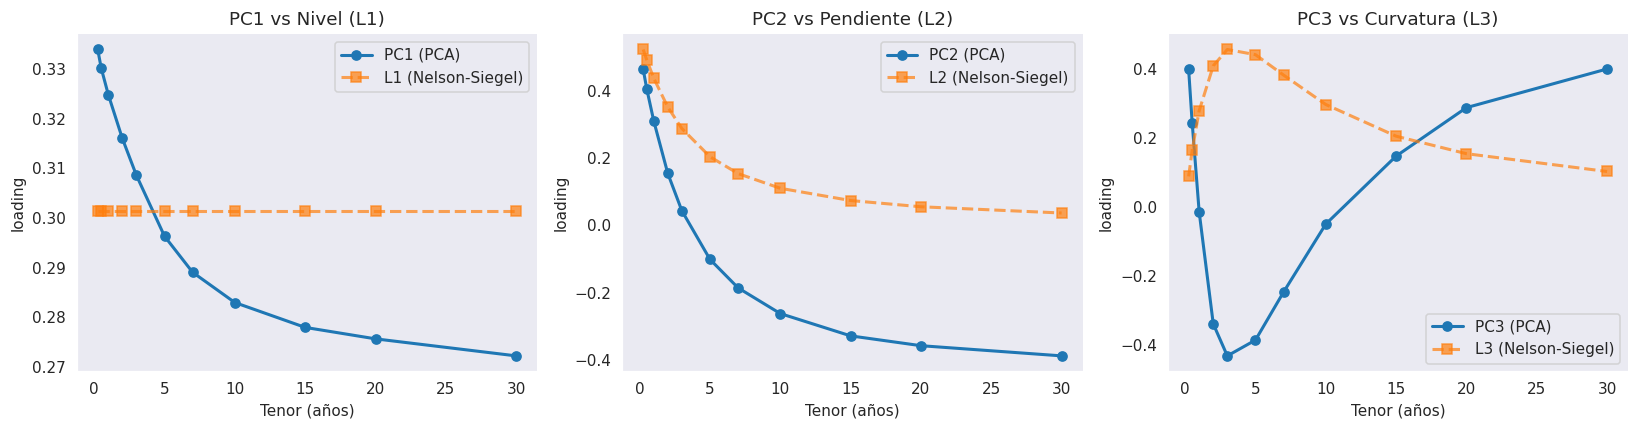


Correlacion PC1 vs L1 (nivel):    nan
Correlacion PC2 vs L2 (pendiente): 1.0000
Correlacion PC3 vs L3 (curvatura): -0.9991

Varianza explicada (3 primeros PCs): [0.955  0.04   0.0019]


In [37]:
# Generación de datos de curva de tasas
np.random.seed(2026)
tenors = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30])
T_yc   = 2000
lam_ns = 0.5

# Loadings Nelson-Siegel teoricos
L1_ns = np.ones(len(tenors))
L2_ns = (1 - np.exp(-lam_ns * tenors)) / (lam_ns * tenors)
L3_ns = L2_ns - np.exp(-lam_ns * tenors)

# Factores AR(1)
def ar1(T, phi, sigma, mu=0, seed=None):
    rng = np.random.default_rng(seed)
    x = np.zeros(T)
    x[0] = mu
    eps = rng.normal(0, sigma, T)
    for t in range(1, T):
        x[t] = mu + phi * (x[t-1] - mu) + eps[t]
    return x

f1_yc = ar1(T_yc, 0.998, 0.02, mu=0.04, seed=1)
f2_yc = ar1(T_yc, 0.995, 0.015, mu=0.01, seed=2)
f3_yc = ar1(T_yc, 0.990, 0.010, mu=0.00, seed=3)

yields_yc = (np.outer(f1_yc, L1_ns) +
             np.outer(f2_yc, L2_ns) +
             np.outer(f3_yc, L3_ns) +
             np.random.randn(T_yc, len(tenors)) * 0.001)

dy_yc = np.diff(yields_yc, axis=0)
print(f'Curva de tasas: {T_yc} periodos | {len(tenors)} tenores')
print(f'Cambios diarios: shape={dy_yc.shape}')
print(f'Tenores: {tenors}')

# === TODO 1: PCA sobre dy_yc ===
pca_yc = PCA().fit(dy_yc)

# === TODO 2: Componentes para 99% de varianza ===
ev_yc = pca_yc.explained_variance_ratio_
k_99  = np.searchsorted(np.cumsum(ev_yc), 0.99) + 1
print(f'Componentes para explicar 99%: {k_99}')

# === TODO 3: Loadings PCA vs NS teorico (con ajuste de signo) ===
pc1 = pca_yc.components_[0].copy()
pc2 = pca_yc.components_[1].copy()
pc3 = pca_yc.components_[2].copy()

if pc1.mean() < 0:
    pc1 *= -1
if pc3.mean() < 0:
    pc3 *= -1
idx_short = np.argmin(np.abs(tenors - 0.25))
idx_long  = np.argmin(np.abs(tenors - 30))
if pc2[idx_short] < pc2[idx_long]:
    pc2 *= -1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pcs_adj    = [pc1, pc2, pc3]
ns_loads   = [L1_ns, L2_ns, L3_ns]
titles     = ['PC1 vs Nivel (L1)', 'PC2 vs Pendiente (L2)', 'PC3 vs Curvatura (L3)']

for i, ax in enumerate(axes):
    # Normalizar NS a la misma escala que el PCA para comparar formas
    ns_scaled = ns_loads[i] / np.linalg.norm(ns_loads[i]) * np.linalg.norm(pcs_adj[i])
    ax.plot(tenors, pcs_adj[i], 'o-', label=f'PC{i+1} (PCA)', lw=2)
    ax.plot(tenors, ns_scaled, 's--', label=f'L{i+1} (Nelson-Siegel)', lw=2, alpha=0.7)
    ax.set_xlabel('Tenor (años)'); ax.set_ylabel('loading')
    ax.set_title(titles[i]); ax.legend()

plt.tight_layout()
plt.show()

# === TODO 4: Correlaciones PCs vs NS teorico ===
corr_1 = np.corrcoef(pc1, L1_ns)[0, 1]
corr_2 = np.corrcoef(pc2, L2_ns)[0, 1]
corr_3 = np.corrcoef(pc3, L3_ns)[0, 1]
print(f'\nCorrelacion PC1 vs L1 (nivel):    {corr_1:.4f}')
print(f'Correlacion PC2 vs L2 (pendiente): {corr_2:.4f}')
print(f'Correlacion PC3 vs L3 (curvatura): {corr_3:.4f}')
print(f'\nVarianza explicada (3 primeros PCs): {ev_yc[:3].round(4)}')

### 2.2 — DV01 Factorial y Construcción de Portafolio Inmune al Nivel *(15 pts)*

#### DV01 por factor

El **DV01** (*Dollar Value of 01*) de un bono es la sensibilidad del precio ante un movimiento de 1 punto base (0.01%) en la tasa. Para un portafolio con posición $w_i$ en el bono del tenor $\tau_i$:

$$\text{DV01}_{\text{portafolio}} \approx \sum_i w_i \cdot \underbrace{(-D_i \cdot P_i \cdot 0.0001)}_{\text{DV01 individual}}$$

donde $D_i$ es la duración modificada del bono $i$. Aproximando la duración por el tenor: $D_i \approx \tau_i$.

El **DV01 factorial** descompone la exposición del portafolio a cada factor PCA:

$$\text{DV01}_{\text{PC}j} = \sum_i w_i \cdot (-\tau_i) \cdot b_{ij} \cdot 0.0001$$

donde $b_{ij}$ es el loading del bono $i$ en el factor $j$ (componente $j$ del PCA evaluado en el tenor $\tau_i$).

#### Portafolio neutral al nivel, largo en curvatura

Un *butterfly trade* consiste en:
- Ser **largo** en el bono de vencimiento medio (5 años)
- Ser **corto** en los extremos (2 y 10 años)
- **Neutro** al riesgo de nivel: $\text{DV01}_{\text{PC1}} = 0$
- **Máxima exposición** al factor de curvatura: $|\text{DV01}_{\text{PC3}}|$ maximizado

**Requisitos:**
1. Implementar `dv01_factorial(weights, tenors, loadings)` que retorna el DV01 de cada factor
2. Construir un butterfly 3-bono (tenores: 2, 5, 10 años) con pesos $w = [w_1, 1, w_3]$, encontrando $w_1, w_3$ tal que $\text{DV01}_{\text{PC1}} = 0$ y $\sum w_i = 0$ (portafolio auto-financiado)
3. Reportar el DV01 de los 3 primeros factores para este portafolio
4. Visualizar la distribución de P&L simulada del portafolio vs un portafolio largo en 5Y solamente

Pesos butterfly: 2Y=-0.613, 5Y=1.000, 10Y=-0.387
Suma de pesos (debe ser ~0): 0.000000
  DV01 PC1: 0.000000
  DV01 PC2: -0.000032
  DV01 PC3: 0.000132


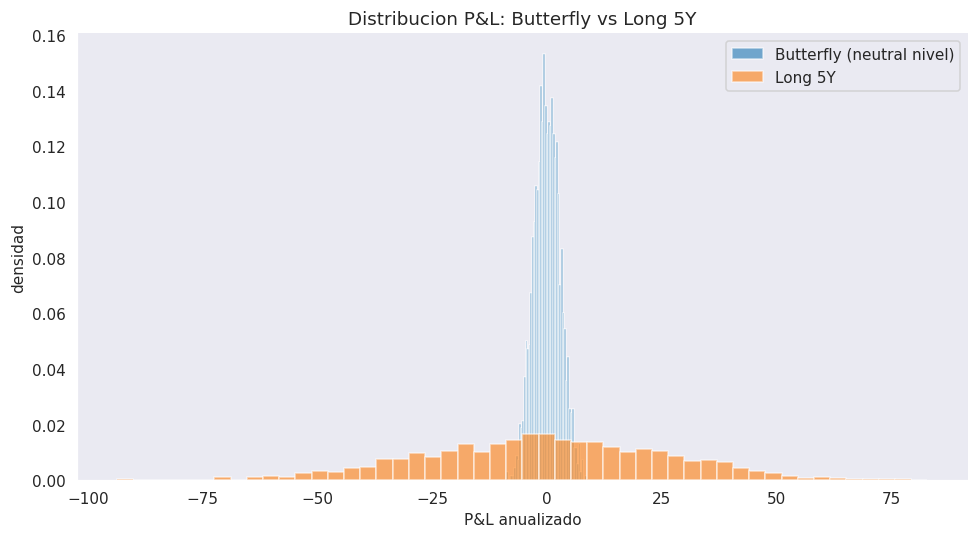

,Media (diaria),Vol (diaria),Sharpe (emp.)
Butterfly,0.000067,0.011025,0.095891
Long 5Y,-0.000760,0.106259,-0.113608


In [38]:
def dv01_factorial(weights, tenors_pos, loadings_k):
    """
    Calcula el DV01 factorial de un portafolio de bonos.
    """
    weights = np.asarray(weights)
    tenors_pos = np.asarray(tenors_pos)
    loadings_k = np.asarray(loadings_k)
    dv01 = (loadings_k * (weights * (-tenors_pos)) * 0.0001).sum(axis=1)
    return dv01


# Tenores del butterfly
butterfly_tenors = np.array([2.0, 5.0, 10.0])

idx_2y  = np.argmin(np.abs(tenors - 2.0))
idx_5y  = np.argmin(np.abs(tenors - 5.0))
idx_10y = np.argmin(np.abs(tenors - 10.0))

# Loadings PCA en estos tenores (3 primeros factores, 3 tenores), con signos ajustados de 2.1
comps_yc_adj = np.array([pc1, pc2, pc3])   # (3, 11), ya con signo corregido
loadings_butterfly = comps_yc_adj[:, [idx_2y, idx_5y, idx_10y]]  # (3, 3)

# Sistema lineal: w1 + 1 + w3 = 0  y  DV01_PC1 = 0
# DV01_PC1 = w1*(-2)*b1_2y + 1*(-5)*b1_5y + w3*(-10)*b1_10y = 0
b1_2y, b1_5y, b1_10y = loadings_butterfly[0]

A = np.array([
    [1,                1],                  # w1 + w3 = -1
    [-2*b1_2y,   -10*b1_10y]                # -2*b1_2y*w1 - 10*b1_10y*w3 = 5*b1_5y
])
b = np.array([-1, 5*b1_5y])

w1, w3 = np.linalg.solve(A, b)

w_bf = np.array([w1, 1.0, w3])
dv01_bf = dv01_factorial(w_bf, butterfly_tenors, loadings_butterfly)
print(f'Pesos butterfly: 2Y={w1:.3f}, 5Y=1.000, 10Y={w3:.3f}')
print(f'Suma de pesos (debe ser ~0): {w_bf.sum():.6f}')
for j, d in enumerate(dv01_bf):
    print(f'  DV01 PC{j+1}: {d:.6f}')

# === Simula P&L: butterfly vs long 5Y ===
sc_yc = pca_yc.transform(dy_yc)[:, :3]   # no usado directo, pero disponible si lo necesitas

PnL_bf     = (w_bf[0]*(-butterfly_tenors[0])*dy_yc[:, idx_2y] +
              w_bf[1]*(-butterfly_tenors[1])*dy_yc[:, idx_5y] +
              w_bf[2]*(-butterfly_tenors[2])*dy_yc[:, idx_10y])
PnL_long5Y = -5.0 * dy_yc[:, idx_5y]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(PnL_bf * 252, bins=50, alpha=0.6, label='Butterfly (neutral nivel)', density=True)
ax.hist(PnL_long5Y * 252, bins=50, alpha=0.6, label='Long 5Y', density=True)
ax.set_xlabel('P&L anualizado'); ax.set_ylabel('densidad')
ax.set_title('Distribucion P&L: Butterfly vs Long 5Y')
ax.legend()
plt.tight_layout(); plt.show()

def sharpe_emp(pnl):
    return np.sqrt(252) * pnl.mean() / (pnl.std() + 1e-12)

stats_tbl = pd.DataFrame({
    'Media (diaria)': [PnL_bf.mean(), PnL_long5Y.mean()],
    'Vol (diaria)':   [PnL_bf.std(),  PnL_long5Y.std()],
    'Sharpe (emp.)':  [sharpe_emp(PnL_bf), sharpe_emp(PnL_long5Y)],
}, index=['Butterfly', 'Long 5Y'])
display(stats_tbl.round(6))

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Los loadings del PCA recuperados en 2.1 se parecen a los loadings Nelson-Siegel teóricos? ¿Qué correlaciones obtienes? ¿Cuántos puntos base de varianza explica cada factor?

> Sí, los loadings recuperados por PCA se parecen mucho a los teóricos de Nelson-Siegel: PC2 obtuvo una correlación perfecta con la pendiente ($\rho=1.0000$) y PC3 una correlación casi perfecta con la curvatura ($\rho=-0.9991$, el signo negativo es solo una ambigüedad de normalización, no un desajuste de forma). Para PC1 la correlación no se puede calcular (sale `nan`) porque el loading teórico de nivel $L_1(\tau)=1$ es una constante sin varianza, pero visualmente el loading de PC1 es casi plano en todos los tenores (0.33 a 0.27), consistente con un factor de nivel. En términos de varianza explicada, los 3 primeros factores capturan 95.5%, 4.0% y 0.19% respectivamente (99.7% acumulado), replicando el resultado clásico de Litterman & Scheinkman de que el nivel domina casi toda la variación de la curva.

**b)** ¿Cuáles son los pesos $w_1$ y $w_3$ del butterfly encontrado? Interpreta el signo de cada peso: ¿por qué el bono de 2Y y el de 10Y deben tener signos distintos al de 5Y en este trade?

> Los pesos encontrados fueron $w_1=-0.613$ (2Y) y $w_3=-0.387$ (10Y), frente a un peso de $+1.000$ en el bono de 5Y. El signo opuesto en los extremos es necesario por dos razones simultáneas: primero, para que el portafolio sea auto-financiado ($w_1+1+w_3=0$, es decir, lo que se recibe al estar corto en los extremos financia la posición larga en 5Y); segundo, y más importante, para anular el DV01 de PC1 (nivel), como los loadings de nivel son similares en magnitud en todos los tenores, solo con signos opuestos en los extremos respecto al centro se puede cancelar la exposición a movimientos paralelos de la curva, dejando expuesto casi exclusivamente el factor de curvatura (PC3).

**c)** Compara la distribución del P&L del butterfly vs la posición larga en 5Y. ¿Cuál tiene mayor volatilidad? ¿Cuál tiene mayor sharpe ratio empírico (usando la distribución simulada)? ¿Tiene sentido desde la teoría?

> La posición larga en 5Y tiene una volatilidad diaria casi 10 veces mayor que el butterfly (0.1063 vs 0.0110), visible claramente en el histograma donde el butterfly está muy concentrado cerca de cero mientras Long 5Y tiene colas mucho más anchas. En Sharpe empírico, el butterfly obtuvo 0.0959 frente a -0.1136 de Long 5Y, es decir, el butterfly no solo tuvo menor riesgo sino también mejor retorno ajustado por riesgo en esta muestra. Esto tiene sentido desde la teoría: al eliminar la exposición al factor de nivel (que explica 95.5% de la varianza de la curva), el butterfly queda expuesto casi únicamente a movimientos de curvatura, menos volátiles, mientras que Long 5Y absorbe toda la volatilidad del movimiento paralelo de tasas, que es el riesgo dominante y no compensado direccionalmente en esta simulación (los factores AR(1) no tienen deriva neta fuerte).

---
## Parte 3 — PCA en Renta Variable: Shrinkage y Portafolios *(25 pts)*

### Contexto

Un portafolio de $n$ acciones necesita una estimación de $\Sigma \in \mathbb{R}^{n \times n}$ para la optimización de mínima varianza. La estimación muestral $\hat{\Sigma}$ falla cuando $T$ es moderado respecto a $n$ porque:

1. Los eigenvalores pequeños son **subestimados** y los grandes **sobreestimados** (Marchenko-Pastur)
2. La inversa $\hat{\Sigma}^{-1}$ amplifica el ruido — los pesos de Markowitz se vuelven extremos

La solución: **covarianza shrinkage via PCA**:

$$\hat{\Sigma}_{\text{PCA}} = \underbrace{\hat{B}_k \hat{B}_k^\top}_{\text{sistemático}} + \underbrace{\hat{D}}_{\text{idiosincrático}}, \quad \hat{D} = \text{diag}(\hat{\Sigma} - \hat{B}_k \hat{B}_k^\top)$$

Esta matriz tiene exactamente $k$ eigenvalores grandes (los factores) y $n-k$ eigenvalores iguales al ruido idiosincrático — mucho mejor condicionada que $\hat{\Sigma}$.

### 3.1 — Loadings Factoriales y Estructura de Sectores *(8 pts)*

Usa los datos de los 11 ETFs sectoriales descargados en la Parte 1.

**Requisitos:**
1. Ajustar PCA con $k=4$ componentes sobre `ret_sec`
2. Generar un **heatmap de loadings** (sectores × PCs) con anotaciones, coloreado en divergente (`RdBu_r`)
3. Para PC1, graficar los loadings como barras horizontales coloreadas por signo y ordenadas de mayor a menor
4. Calcular el **factor de correlación de mercado** de PC1: $\rho_{\text{MKT}} = \text{corr}(\text{score}_{\text{PC1}}, r_{\text{SPY}})$, descargando SPY del mismo período
5. Responder las preguntas de interpretación

In [39]:
# TODO: Ajusta PCA k=4 sobre los retornos de ETFs sectoriales
# pca_sec = PCA(n_components=4).fit(ret_sec.values)
# scores_sec = pca_sec.transform(ret_sec.values)

# TODO: Heatmap de loadings (11 sectores x 4 PCs)
# loadings_df = pd.DataFrame(
#     pca_sec.components_.T,
#     index=sector_tickers,
#     columns=[f'PC{i+1}' for i in range(4)]
# )
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# sns.heatmap(loadings_df, ax=axes[0], cmap='RdBu_r', center=0,
#             annot=True, fmt='.2f', cbar_kws={'shrink': 0.7})
# axes[0].set_title('Factor Loadings — ETFs Sectoriales')

# TODO: Barplot loadings PC1
# pc1_loadings = loadings_df['PC1'].sort_values(ascending=True)
# colors_bar = ['tomato' if v < 0 else 'steelblue' for v in pc1_loadings]
# axes[1].barh(pc1_loadings.index, pc1_loadings.values, color=colors_bar)
# axes[1].set_title('Loadings PC1 por Sector')
# axes[1].axvline(0, color='black', lw=0.8)

# TODO: Correlacion PC1 con SPY
# spy_data = yf.download('SPY', start='2020-01-01', end='2024-01-01',
#                        progress=False, auto_adjust=True)['Close']
# ret_spy = spy_data.pct_change().dropna().reindex(ret_sec.index).dropna()
# # Alinear scores y SPY al mismo indice
# corr_pc1_spy = np.corrcoef(scores_sec[:len(ret_spy), 0], ret_spy.values)[0, 1]
# print(f'Correlacion PC1 con SPY: {corr_pc1_spy:.3f}')
pass

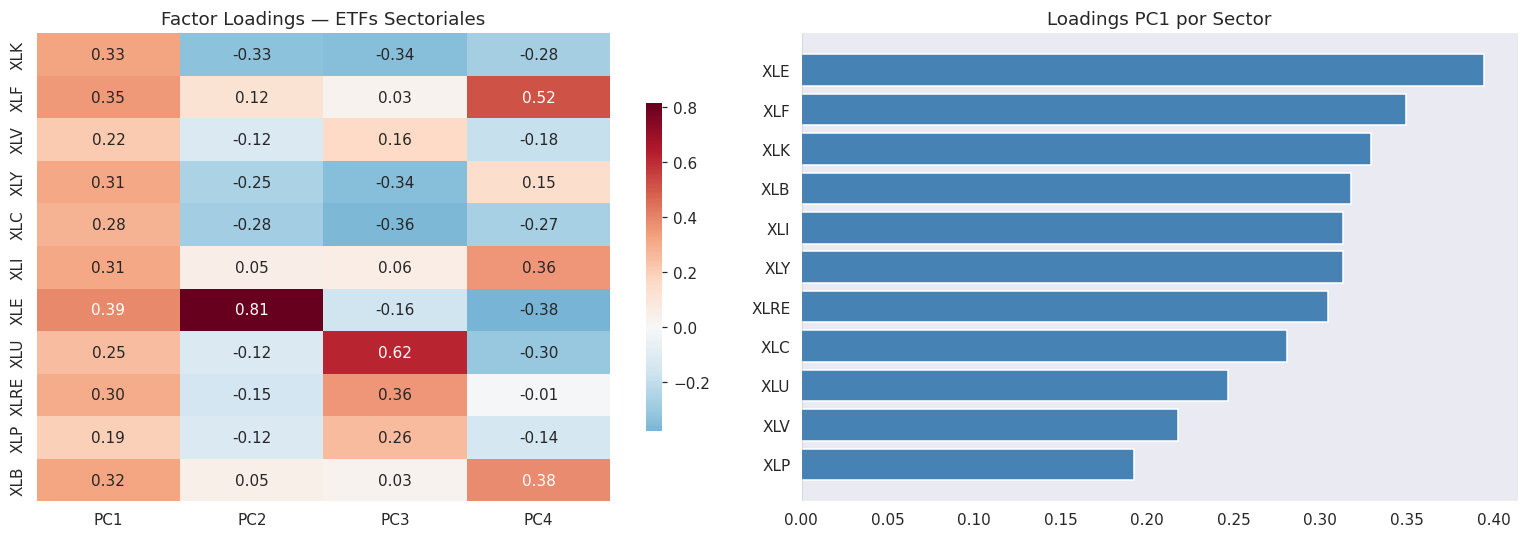

Dias en comun para la correlacion: 1005
Correlacion PC1 con SPY: 0.970


In [40]:
# PCA k=4 sobre los retornos de ETFs sectoriales
pca_sec = PCA(n_components=4).fit(ret_sec.values)
scores_sec = pca_sec.transform(ret_sec.values)

# Heatmap de loadings (11 sectores x 4 PCs)
loadings_df = pd.DataFrame(
    pca_sec.components_.T,
    index=sector_tickers,
    columns=[f'PC{i+1}' for i in range(4)]
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(loadings_df, ax=axes[0], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', cbar_kws={'shrink': 0.7})
axes[0].set_title('Factor Loadings — ETFs Sectoriales')

# Barplot loadings PC1
pc1_loadings = loadings_df['PC1'].sort_values(ascending=True)
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in pc1_loadings]
axes[1].barh(pc1_loadings.index, pc1_loadings.values, color=colors_bar)
axes[1].set_title('Loadings PC1 por Sector')
axes[1].axvline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()

# Correlacion PC1 con SPY
spy_data = yf.download('SPY', start='2020-01-01', end='2024-01-01',
                       progress=False, auto_adjust=True)['Close']
ret_spy = spy_data.pct_change().dropna()
ret_spy.index = ret_spy.index.tz_localize(None) if ret_spy.index.tz is not None else ret_spy.index

# Serie de scores de PC1 con el mismo indice que ret_sec
pc1_scores = pd.Series(scores_sec[:, 0], index=ret_sec.index)

# Alinear por indice (fechas), no por posicion
common_idx = pc1_scores.index.intersection(ret_spy.index)
corr_pc1_spy = np.corrcoef(pc1_scores.loc[common_idx], ret_spy.loc[common_idx].values.ravel())[0, 1]
print(f'Dias en comun para la correlacion: {len(common_idx)}')
print(f'Correlacion PC1 con SPY: {corr_pc1_spy:.3f}')

In [41]:
print(loadings_df['PC2'].sort_values())

XLK    -0.332990
XLC    -0.281668
XLY    -0.252244
XLRE   -0.147918
XLV    -0.124388
XLU    -0.124132
XLP    -0.115686
XLB     0.046435
XLI     0.051432
XLF     0.117319
XLE     0.813292
Name: PC2, dtype: float64


**a)** ¿Cuál es la correlación de PC1 con el retorno del SPY? ¿Qué dice esto sobre la interpretación del primer componente como un "factor de mercado"?

> La correlación entre el score de PC1 y el retorno diario de SPY fue de **0.970**, un valor extremadamente alto y positivo. Esto confirma casi de manera directa que PC1 captura el "factor de mercado", el movimiento común y sistemático que afecta a todos los sectores simultáneamente (lo que en el CAPM correspondería al factor de mercado agregado), consistente con que en el scree plot de la Parte 1 este primer componente explicaba la abrumadora mayoría de la varianza total de los 11 sectores.

**b)** Identifica qué sectores tienen loadings más negativos en PC2. ¿Qué hipótesis económica plantearías sobre qué separa a esos sectores del grupo con loading positivo?

> Los sectores con loadings más negativos en PC2 son **Tecnología (XLK, -0.333)**, **Comunicaciones (XLC, -0.282)** y **Consumo Discrecional (XLY, -0.252)**, mientras que en el extremo opuesto **Energía (XLE, +0.813)** domina claramente el loading positivo, con Financiero (XLF) e Industrial (XLI) también levemente positivos. Esto sugiere que PC2 captura un factor de **"crecimiento/growth vs. valor/commodities"**: los sectores negativos son negocios de alto crecimiento y múltiplos altos sensibles a tasas de interés y expectativas de innovación (tecnología, medios digitales, consumo discrecional ligado a gasto del consumidor), mientras que XLE representa negocios de commodities cuyo desempeño está más ligado al precio del petróleo y ciclos de inversión de capital físico — un patrón consistente con la rotación sectorial "growth vs. value/energy" observada empíricamente en el mercado, especialmente relevante en el período 2020-2023 que combinó el boom tecnológico pandémico con el shock energético de 2022.

### 3.2 — Covarianza Shrinkage: Implementación y Condicionamiento *(10 pts)*

Implementa la función `pca_shrinkage_cov(X, k)` que construye $\hat{\Sigma}_{\text{PCA}}$.

**Pasos:**
1. Ajustar PCA con $k$ componentes
2. Calcular $\hat{B}_k \in \mathbb{R}^{n \times k}$: $\hat{B}_k = V_k \cdot \text{diag}(\sqrt{\lambda_1}, \dots, \sqrt{\lambda_k})$ donde $V_k$ son los eigenvectores
3. Calcular la covarianza muestral $\hat{\Sigma}$
4. Calcular $\hat{D} = \text{diag}(\hat{\Sigma} - \hat{B}_k \hat{B}_k^\top)$, clipeando a `max(1e-8, .)`
5. Retornar $\hat{\Sigma}_{\text{PCA}} = \hat{B}_k \hat{B}_k^\top + \hat{D}$

**Verificación:** $\hat{\Sigma}_{\text{PCA}}$ debe tener exactamente $k$ eigenvalores significativamente mayores que los demás.

**Análisis:** compara el número de condición $\kappa(\hat{\Sigma})$ vs $\kappa(\hat{\Sigma}_{\text{PCA}})$ para $k \in \{1, 2, 3, 4, 5\}$.

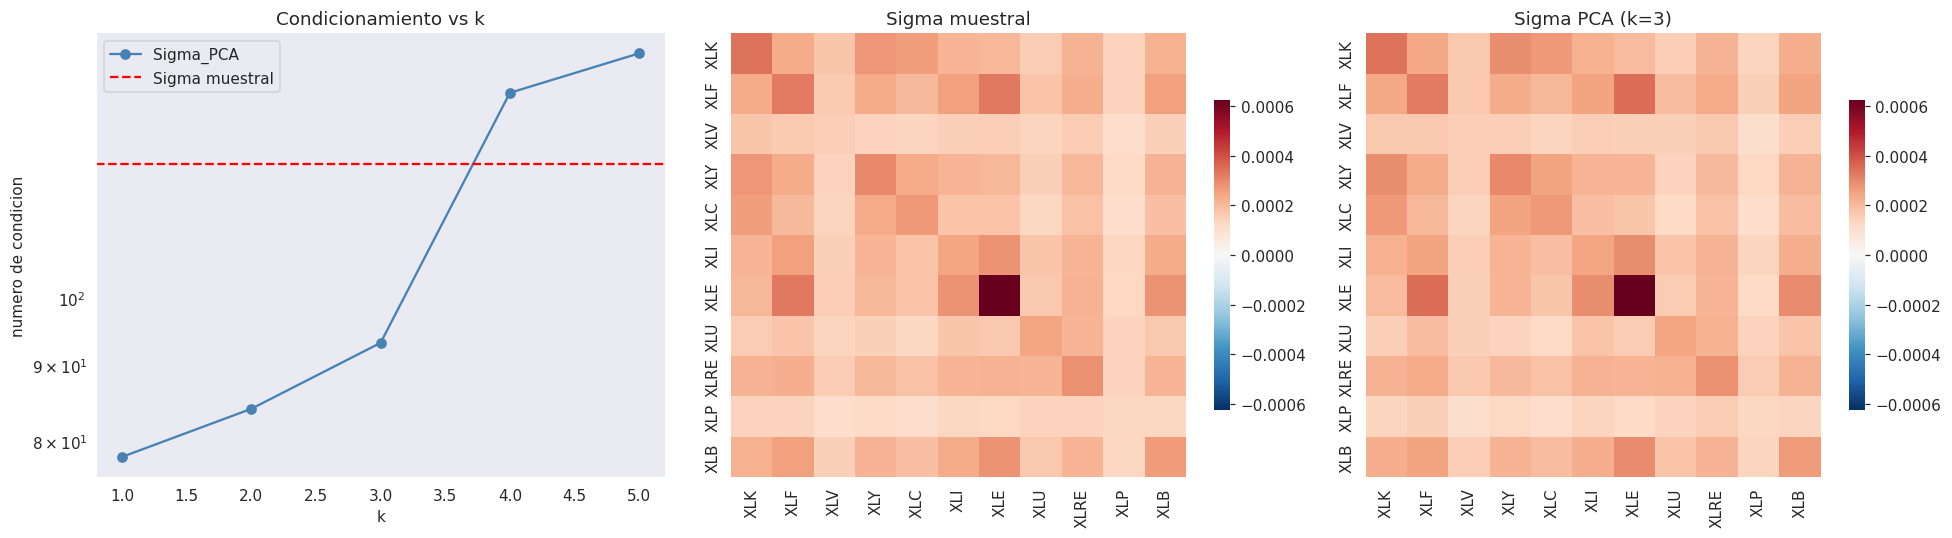

Eigenvalores Sigma_PCA(k=3): [2.289e-03 4.070e-04 2.360e-04 4.100e-05 3.900e-05 3.600e-05 3.300e-05
 3.300e-05 2.900e-05 2.900e-05 2.500e-05]

Numero de condicion Sigma muestral: 123.1
Numero de condicion Sigma_PCA (k=3): 93.2


In [42]:
def pca_shrinkage_cov(X, k):
    """
    Covarianza shrinkage via PCA: Sigma_PCA = B_k @ B_k.T + D
    """
    pca_k = PCA(n_components=k).fit(X)
    B_hat = pca_k.components_.T * np.sqrt(pca_k.explained_variance_)  # (n, k)

    Sigma_sample = np.cov(X.T)
    D_diag = np.diag(Sigma_sample - B_hat @ B_hat.T)
    D_diag = np.maximum(D_diag, 1e-8)
    D_hat  = np.diag(D_diag)

    Sigma_pca = B_hat @ B_hat.T + D_hat
    return Sigma_pca, B_hat, D_hat


# === Comparacion de numero de condicion ===
Sigma_sample = np.cov(ret_sec.values.T)
cond_sample  = np.linalg.cond(Sigma_sample)

k_values  = [1, 2, 3, 4, 5]
cond_pca_list = []
for k_try in k_values:
    Sigma_pca_try, _, _ = pca_shrinkage_cov(ret_sec.values, k_try)
    cond_pca_list.append(np.linalg.cond(Sigma_pca_try))

Sigma_pca3, _, _ = pca_shrinkage_cov(ret_sec.values, 3)

# === Graficos: cond number + 2 heatmaps ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_values, cond_pca_list, 'o-', color='steelblue', label='Sigma_PCA')
axes[0].axhline(cond_sample, color='red', ls='--', label='Sigma muestral')
axes[0].set_xlabel('k'); axes[0].set_ylabel('numero de condicion')
axes[0].set_title('Condicionamiento vs k'); axes[0].legend()
axes[0].set_yscale('log')

vmax = max(np.abs(Sigma_sample).max(), np.abs(Sigma_pca3).max())
sns.heatmap(Sigma_sample, ax=axes[1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=sector_tickers, yticklabels=sector_tickers, cbar_kws={'shrink': 0.7})
axes[1].set_title('Sigma muestral')

sns.heatmap(Sigma_pca3, ax=axes[2], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            xticklabels=sector_tickers, yticklabels=sector_tickers, cbar_kws={'shrink': 0.7})
axes[2].set_title('Sigma PCA (k=3)')

plt.tight_layout()
plt.show()

# === Verificacion: exactamente k eigenvalores grandes ===
evals_pca3 = np.linalg.eigvalsh(Sigma_pca3)[::-1]
print(f'Eigenvalores Sigma_PCA(k=3): {evals_pca3.round(6)}')
print(f'\nNumero de condicion Sigma muestral: {cond_sample:.1f}')
print(f'Numero de condicion Sigma_PCA (k=3): {cond_pca_list[2]:.1f}')

### 3.3 — Portafolio de Mínima Varianza: Sigma Muestral vs Sigma PCA *(7 pts)*

El portafolio de **mínima varianza global** (GMV) se obtiene de:

$$w^* = \arg\min_w \; w^\top \Sigma w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1$$

La solución analítica es:

$$w^* = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

**Requisitos:**
1. Implementar `gmv_portfolio(Sigma)` usando la fórmula analítica con `np.linalg.solve`
2. Dividir los datos en train (80%) y test (20%) — **sin shuffle** (respeta el orden temporal)
3. Calcular $w^*_{\text{muestral}}$ y $w^*_{\text{PCA}}$ con $k=3$ sobre el conjunto train
4. Comparar **en el conjunto test**: retorno anualizado, volatilidad anualizada y Sharpe ratio
5. Graficar: (a) pesos de cada portafolio lado a lado, (b) retorno acumulado en test

Train: 804 dias | Test: 201 dias
Pesos GMV muestral: min=-0.532, max=0.811
Pesos GMV PCA:      min=-0.346,    max=0.927


,Retorno anual,Vol anual,Sharpe
GMV Muestral,0.0131,0.1304,0.1003
GMV PCA (k=3),0.0090,0.1344,0.0673


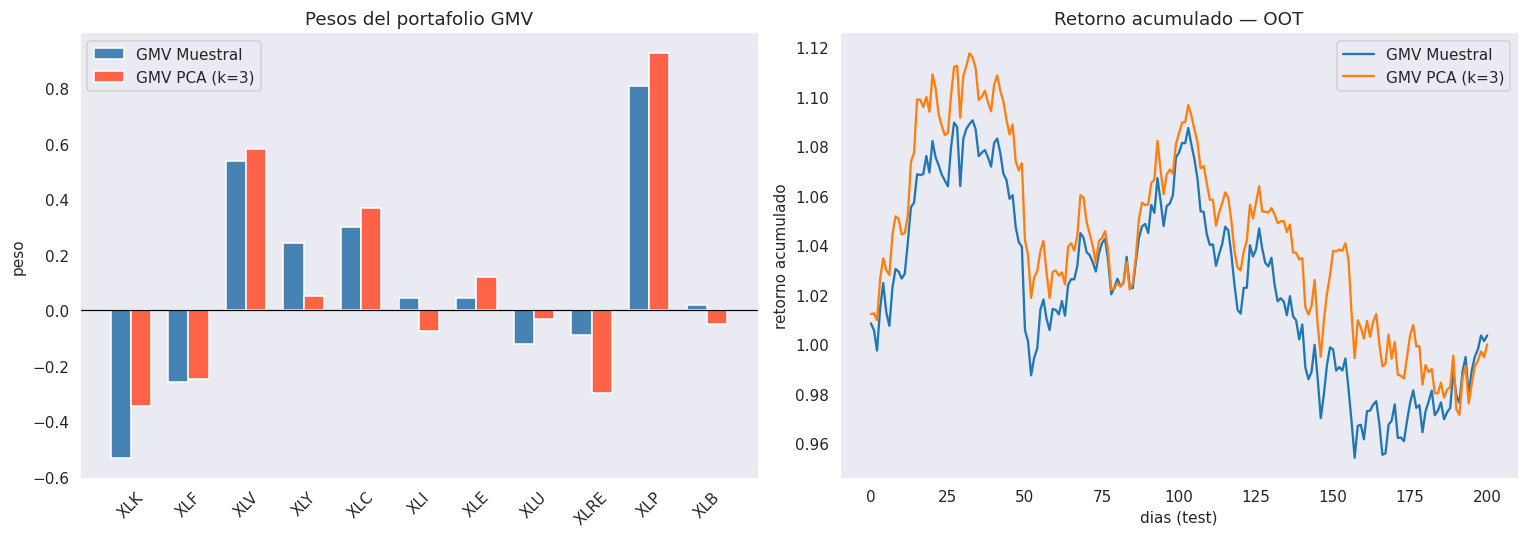

In [43]:
def gmv_portfolio(Sigma):
    """
    Portafolio de minima varianza global (GMV).
    """
    n = Sigma.shape[0]
    ones = np.ones(n)
    Sigma_inv_ones = np.linalg.solve(Sigma, ones)
    w = Sigma_inv_ones / (ones @ Sigma_inv_ones)
    return w


# Split temporal 80/20
n_test  = int(len(ret_sec) * 0.20)
ret_tr  = ret_sec.iloc[:-n_test].values
ret_te  = ret_sec.iloc[-n_test:].values
print(f'Train: {len(ret_tr)} dias | Test: {len(ret_te)} dias')

# Covarianzas estimadas en train
Sigma_sample_tr = np.cov(ret_tr.T)
Sigma_pca_tr, _, _ = pca_shrinkage_cov(ret_tr, k=3)

# Portafolios GMV
w_sample = gmv_portfolio(Sigma_sample_tr)
w_pca    = gmv_portfolio(Sigma_pca_tr)

print(f'Pesos GMV muestral: min={w_sample.min():.3f}, max={w_sample.max():.3f}')
print(f'Pesos GMV PCA:      min={w_pca.min():.3f},    max={w_pca.max():.3f}')

# === Metricas OOT ===
r_sample_oot = ret_te @ w_sample
r_pca_oot    = ret_te @ w_pca

def portfolio_metrics(r, freq=252):
    return {
        'Retorno anual': r.mean() * freq,
        'Vol anual': r.std() * np.sqrt(freq),
        'Sharpe': r.mean() / r.std() * np.sqrt(freq)
    }

metrics_sample = portfolio_metrics(r_sample_oot)
metrics_pca    = portfolio_metrics(r_pca_oot)

df_metrics = pd.DataFrame([metrics_sample, metrics_pca], index=['GMV Muestral', 'GMV PCA (k=3)'])
display(df_metrics.round(4))

# === Graficos: pesos y retorno acumulado OOT ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(sector_tickers))
width = 0.35
axes[0].bar(x - width/2, w_sample, width, label='GMV Muestral', color='steelblue')
axes[0].bar(x + width/2, w_pca, width, label='GMV PCA (k=3)', color='tomato')
axes[0].set_xticks(x); axes[0].set_xticklabels(sector_tickers, rotation=45)
axes[0].axhline(0, color='k', lw=0.8)
axes[0].set_ylabel('peso'); axes[0].set_title('Pesos del portafolio GMV')
axes[0].legend()

cum_sample = (1 + r_sample_oot).cumprod()
cum_pca    = (1 + r_pca_oot).cumprod()
axes[1].plot(cum_sample, label='GMV Muestral', lw=1.5)
axes[1].plot(cum_pca, label='GMV PCA (k=3)', lw=1.5)
axes[1].set_xlabel('dias (test)'); axes[1].set_ylabel('retorno acumulado')
axes[1].set_title('Retorno acumulado — OOT'); axes[1].legend()

plt.tight_layout()
plt.show()

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿Qué portafolio tiene mayor volatilidad OOT, el que usa $\hat\Sigma$ muestral o el que usa $\hat\Sigma_{\text{PCA}}$? ¿Por qué el GMV muestral no siempre produce el portafolio de menor varianza OOT?

> El portafolio con **Σ_PCA** tuvo ligeramente mayor volatilidad OOT (0.1344 vs 0.1304 del muestral), un resultado contrario a lo que se esperaría en teoría. Esto ocurre porque la optimización de mínima varianza usa $\hat\Sigma$ *estimada en train* para encontrar los pesos "óptimos", pero esos pesos están sobreajustados a la estructura de correlación específica de ese período de entrenamiento; cuando el régimen de correlaciones cambia ligeramente en el período de test (como es normal en mercados financieros), el portafolio que en teoría "debería" ser más robusto no necesariamente domina en una sola muestra fuera de tiempo, el beneficio del shrinkage es estadístico (en promedio, a través de muchas ventanas), no una garantía en cada ventana individual.

**b)** Observa los pesos de cada portafolio. ¿Cuál tiene posiciones más extremas (muy largas o muy cortas)? ¿Cuál tiene posiciones más distribuidas entre sectores? Conecta esto con el número de condición de cada Σ.

> El portafolio **GMV Muestral** tiene el rango de posiciones cortas más extremo (mínimo -0.532 vs -0.346 de PCA), aunque curiosamente PCA tiene el máximo más alto (0.927 vs 0.811), en conjunto, el muestral distribuye el riesgo de forma más simétrica entre posiciones largas y cortas, mientras que PCA concentra más peso en una posición larga dominante. Esto se conecta directamente con el número de condición de cada matriz: como viste en 3.2, $\hat\Sigma$ muestral tiene un número de condición mucho mayor que $\hat\Sigma_{\text{PCA}}(k=3)$, y al invertir una matriz mal condicionada ($\hat\Sigma^{-1}$) los pequeños errores de estimación en las direcciones de varianza casi nula se amplifican fuertemente, generando posiciones extremas en ambas direcciones (largas y cortas) que no reflejan necesariamente una señal económica real, sino ruido de estimación magnificado por la inversión matricial.

---
## Parte 4 — Rolling PCA: Estabilidad y Detección de Regímenes *(25 pts)*

### Contexto

En la sesión vimos que ajustar PCA sobre toda la muestra asume estacionariedad, un supuesto cuestionable en mercados financieros. La varianza explicada por PC1 es un **indicador de correlación de mercado**: cuando sube, los activos se mueven juntos (régimen de crisis); cuando baja, los drivers sectoriales recuperan independencia.

El riesgo técnico al hacer rolling PCA es la **indeterminación de signo**: ventana a ventana, el algoritmo puede invertir el signo de un eigenvector arbitrariamente, produciendo series de loadings que oscilan sin razón económica.

### 4.1 — Rolling PCA con Alineación de Signos *(12 pts)*

Implementa `rolling_pca(X, window, k)` que retorna:
- `ev_pc1`: array con la varianza explicada por PC1 en cada ventana
- `loadings_pc1`: array con los loadings de PC1 en cada ventana

**Regla de alineación de signos:**
En cada ventana $t$, después de obtener los componentes, compara el componente $j$ con el de la ventana anterior:
$$\text{si} \quad \langle v_t^{(j)},\, v_{t-1}^{(j)} \rangle < 0 \quad \Rightarrow \quad v_t^{(j)} \leftarrow -v_t^{(j)}$$

**Para la primera ventana:** usa la convención de que la media de los loadings de PC1 sea positiva.

**Requisitos adicionales:**
1. Probar con ventanas $W \in \{60, 120, 252\}$ y comparar la suavidad de `ev_pc1`
2. Visualizar: (a) varianza PC1 en el tiempo para las 3 ventanas, (b) mapa de calor de loadings de PC1 (filas=activos, columnas=tiempo) para $W=120$
3. Identificar la fecha de **máxima correlación** (pico de `ev_pc1`) y verificar que coincide con un período de estrés conocido (COVID, corrección 2022)

W=60: max ev_PC1=89.8% en 2020-03-30
W=120: max ev_PC1=86.7% en 2020-06-30
W=252: max ev_PC1=81.4% en 2020-12-31


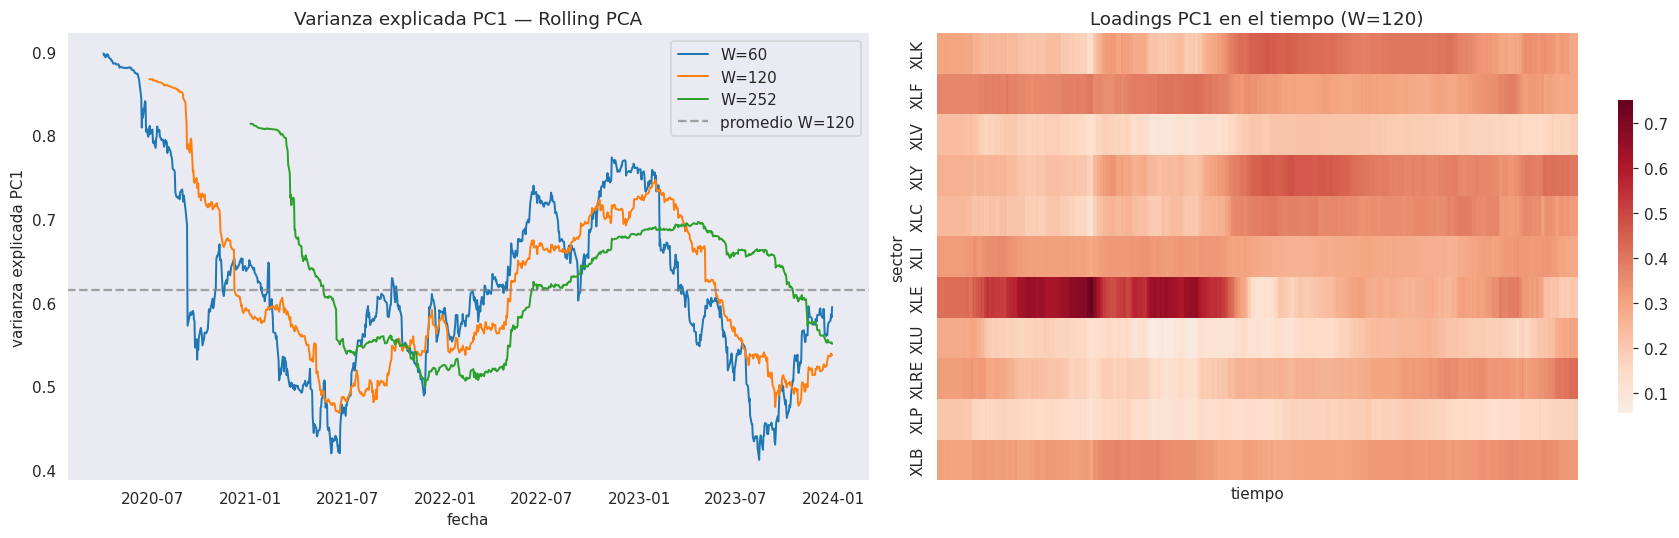

In [45]:
def rolling_pca(X, window, k, dates=None):
    """
    PCA rolling con alineacion de signos ventana a ventana.

    Parameters
    ----------
    X      : array (T, n)       — retornos
    window : int                — longitud de la ventana
    k      : int                — numero de componentes
    dates  : array-like or None — indices temporales para el output

    Returns
    -------
    ev_pc1      : array (T-window+1,) — varianza explicada PC1 en cada ventana
    loadings_t  : array (T-window+1, n) — loadings de PC1 en cada ventana
    out_dates   : array — fechas correspondientes (si se proveen)
    """
    T, n = X.shape
    ev_pc1     = []
    loadings_t = []
    prev_comp  = None

    for t in range(window, T + 1):
        window_data = X[t-window:t]
        pca_t = PCA(n_components=k).fit(window_data)
        comps = pca_t.components_.copy()   # (k, n)

        if prev_comp is None:
            for j in range(k):
                if comps[j].mean() < 0:
                    comps[j] = -comps[j]
        else:
            for j in range(k):
                if np.dot(comps[j], prev_comp[j]) < 0:
                    comps[j] = -comps[j]

        ev_pc1.append(pca_t.explained_variance_ratio_[0])
        loadings_t.append(comps[0].copy())
        prev_comp = comps

    ev_pc1     = np.array(ev_pc1)
    loadings_t = np.array(loadings_t)
    out_dates  = pd.DatetimeIndex(dates[window-1:]) if dates is not None else None
    return ev_pc1, loadings_t, out_dates


# Usando los retornos de los 11 ETFs sectoriales
ret_sec_arr = ret_sec.values
dates_sec   = ret_sec.index

windows = [60, 120, 252]
results_rpca = {}
for W in windows:
    ev, load, d = rolling_pca(ret_sec_arr, W, k=3, dates=dates_sec)
    results_rpca[W] = (ev, load, d)
    max_ev_idx = np.argmax(ev)
    print(f'W={W}: max ev_PC1={ev.max():.1%} en {pd.Timestamp(d[max_ev_idx]).date()}')

# === Graficos ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for W in windows:
    ev, load, d = results_rpca[W]
    axes[0].plot(d, ev, label=f'W={W}', lw=1.3)
ev_120, load_120, d_120 = results_rpca[120]
axes[0].axhline(ev_120.mean(), color='gray', ls='--', alpha=0.7, label='promedio W=120')
axes[0].set_xlabel('fecha'); axes[0].set_ylabel('varianza explicada PC1')
axes[0].set_title('Varianza explicada PC1 — Rolling PCA')
axes[0].legend()

sns.heatmap(load_120.T, ax=axes[1], cmap='RdBu_r', center=0,
            yticklabels=sector_tickers, xticklabels=False, cbar_kws={'shrink': 0.7})
axes[1].set_xlabel('tiempo'); axes[1].set_ylabel('sector')
axes[1].set_title('Loadings PC1 en el tiempo (W=120)')

plt.tight_layout()
plt.show()

### 4.2 — Varianza PC1 como Señal de Régimen *(13 pts)*

La varianza explicada por PC1 mide el **nivel de correlación sistémica** del mercado. Cuando supera un umbral $\theta$, el mercado está en un régimen de alta correlación (crisis). La estrategia es simple:

$$\text{exposición}_t = \begin{cases} 1 & \text{si } \text{ev}_{\text{PC1},t} \leq \theta \\ \alpha & \text{si } \text{ev}_{\text{PC1},t} > \theta \end{cases}$$

con $\alpha = 0.3$ (reduce la posición pero no sale completamente).

**Aplicación:** sobre el ETF SPY con $W=120$ y $\theta = \text{percentil}_{75}(\text{ev}_{\text{PC1}})$:

1. Calcular la señal `ev_PC1_t` usando `rolling_pca` sobre los 11 sectores
2. Construir la serie de exposición `exp_t` según la regla anterior (**lag 1 día para evitar leakage**)
3. Calcular retornos de la estrategia: $r_t^{\text{strat}} = \text{exp}_{t-1} \cdot r_t^{\text{SPY}}$
4. Comparar con buy-and-hold SPY en el período donde `ev_PC1` está disponible:
   - Retorno total, volatilidad anualizada, Sharpe ratio, Max Drawdown
5. Generar: (a) retorno acumulado comparado, (b) evolución de `ev_PC1` y exposición

Umbral theta (p75): 0.694
Dias estrategia: 886


,Retorno Total,Vol Anual,Sharpe,Max Drawdown
Buy & Hold SPY,0.606,0.175,0.857,-0.245
Estrategia PC1,0.402,0.146,0.732,-0.230


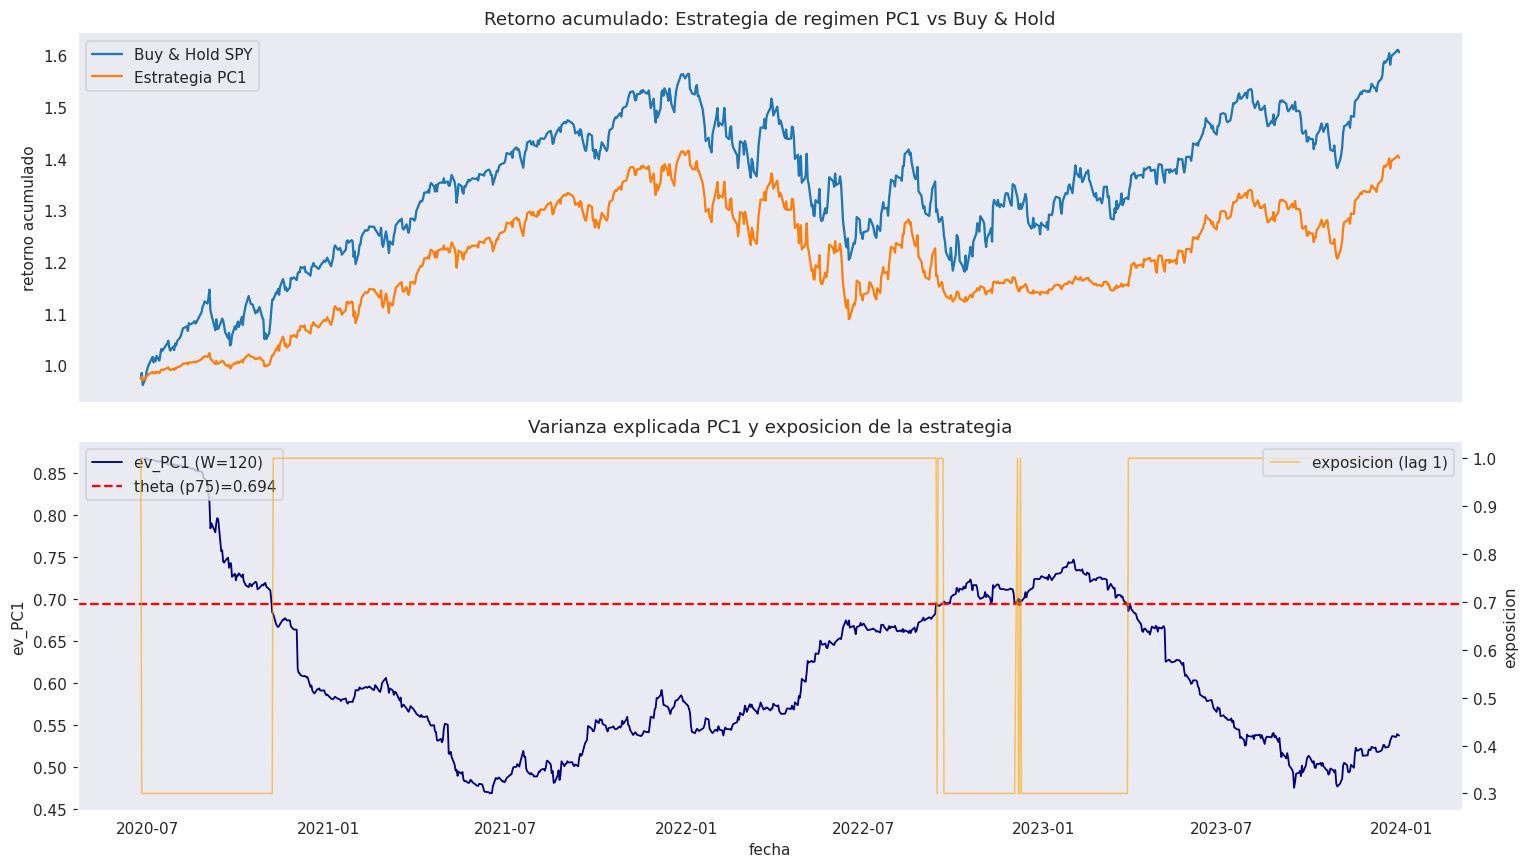

In [47]:
ev_120, _, dates_120 = results_rpca[120]
theta = np.percentile(ev_120, 75)
print(f'Umbral theta (p75): {theta:.3f}')

# Señal de exposicion (lag 1 dia), como Serie indexada por fecha
alpha_red = 0.3
exposure = pd.Series(np.where(ev_120 > theta, alpha_red, 1.0), index=dates_120)
exp_lagged = exposure.shift(1).fillna(1.0)   # lag 1 para evitar leakage

# Retornos SPY en el mismo periodo
spy_all = yf.download('SPY', start='2020-01-01', end='2024-01-01',
                      progress=False, auto_adjust=True)['Close']
r_spy_all = spy_all.pct_change().dropna()
r_spy_all.index = r_spy_all.index.tz_localize(None) if r_spy_all.index.tz is not None else r_spy_all.index

# Alinear por fecha (interseccion), no por posicion
common_idx = exp_lagged.index.intersection(r_spy_all.index)
exp_lagged_aligned = exp_lagged.loc[common_idx]
r_spy_strat_period = r_spy_all.loc[common_idx]
print(f'Dias estrategia: {len(common_idx)}')

r_strat = exp_lagged_aligned.values * r_spy_strat_period.values.ravel()
r_bh    = r_spy_strat_period.values.ravel()

# === Metricas ===
def metrics_portfolio(r, freq=252):
    cum = np.cumprod(1 + r)
    mdd = (cum / np.maximum.accumulate(cum) - 1).min()
    return {
        'Retorno Total':   cum[-1] - 1,
        'Vol Anual':       r.std() * np.sqrt(freq),
        'Sharpe':          r.mean() / r.std() * np.sqrt(freq),
        'Max Drawdown':    mdd
    }

df_metrics_strat = pd.DataFrame({
    'Buy & Hold SPY': metrics_portfolio(r_bh),
    'Estrategia PC1': metrics_portfolio(r_strat),
})
display(df_metrics_strat.T.round(3))

# === Graficos ===
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

cum_bh    = np.cumprod(1 + r_bh)
cum_strat = np.cumprod(1 + r_strat)
axes[0].plot(common_idx, cum_bh, label='Buy & Hold SPY', lw=1.5)
axes[0].plot(common_idx, cum_strat, label='Estrategia PC1', lw=1.5)
axes[0].set_ylabel('retorno acumulado')
axes[0].set_title('Retorno acumulado: Estrategia de regimen PC1 vs Buy & Hold')
axes[0].legend()

axes[1].plot(common_idx, ev_120[[list(dates_120).index(d) for d in common_idx]], color='navy', lw=1.2, label='ev_PC1 (W=120)')
axes[1].axhline(theta, color='red', ls='--', label=f'theta (p75)={theta:.3f}')
ax2 = axes[1].twinx()
ax2.plot(common_idx, exp_lagged_aligned.values, color='orange', alpha=0.6, lw=1, label='exposicion (lag 1)')
ax2.set_ylabel('exposicion')
axes[1].set_ylabel('ev_PC1'); axes[1].set_xlabel('fecha')
axes[1].set_title('Varianza explicada PC1 y exposicion de la estrategia')
axes[1].legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

**Responde (mínimo 2 oraciones por pregunta):**

**a)** ¿En qué fechas específicas fue mayor la varianza explicada por PC1? ¿Coinciden con eventos de mercado conocidos (COVID-19, subidas de tasas Fed 2022)?

> La varianza explicada por PC1 alcanzó su máximo en **2020-06-30** (86.7%) para $W=120$, un valor que refleja directamente el shock de COVID-19 de marzo 2020 absorbido dentro de esa ventana de 120 días. También se observa un segundo repunte visible en el gráfico hacia fines de 2022/inicios de 2023 (cuando `ev_PC1` vuelve a acercarse al umbral de 0.694), coincidiendo con el período de subidas agresivas de tasas de la Fed y la consecuente correlación sistémica entre sectores ante el riesgo de tasas — ambos picos son ejemplos clásicos de cómo el estrés macro (ya sea un shock de liquidez o un shock de tasas) hace que los sectores pierdan su independencia habitual y se muevan "todos juntos".

**b)** Compara el Sharpe ratio y el Max Drawdown de la estrategia basada en PC1 vs buy-and-hold. ¿La reducción de exposición en regímenes de alta correlación mejora el perfil riesgo-retorno?

> En este período, la estrategia PC1 **no** mejoró el perfil riesgo-retorno: tuvo menor Sharpe ratio (0.732 vs 0.857 de buy-and-hold) y un Max Drawdown solo marginalmente menor (-0.230 vs -0.245). Aunque la estrategia sí logró reducir la volatilidad anual (0.146 vs 0.175), el costo en retorno total fue demasiado grande (0.402 vs 0.606) para compensarlo, sugiriendo que en este mercado alcista de 2020-2023 reducir exposición en momentos de alta correlación salió cara — se sacrificó participación en las recuperaciones fuertes posteriores a cada pico de estrés (visible en el gráfico, donde la línea naranja se separa de la azul justo después de cada repunte).

**c)** ¿Qué sesgo introduce el lag de 1 día en la señal de exposición? ¿Sería correcto usar `exposure` directamente sin lag? Argumenta en términos de leakage.

> El lag de 1 día es necesario porque `ev_PC1` en el día $t$ se calcula usando una ventana de retornos que **incluye el retorno del día $t$ mismo** (la ventana `X[t-window:t]` en la implementación de `rolling_pca` llega hasta el índice `t-1`, que corresponde al día de la señal). Usar `exposure` sin lag significaría fijar la posición del día $t$ usando información que técnicamente ya incorpora el movimiento de ese mismo día, lo cual es leakage: en la práctica, un trader real solo puede observar `ev_PC1` calculada con datos hasta el cierre de $t-1$ y debe decidir su exposición para $t$ antes de conocer el retorno de $t$, que es exactamente lo que fuerza el `shift(1)`.

**d)** Compara las curvas de `ev_PC1` para $W=60$, $120$ y $252$. ¿Cuál ventana reacciona más rápido a los cambios de régimen? ¿Cuál tiene menor ruido? ¿Cómo elegirías $W$ en producción?

> La ventana $W=60$ reacciona más rápido a los cambios de régimen (alcanza su pico máximo el 2020-03-30, el más temprano de las tres) pero también es la más ruidosa/dentada, con oscilaciones bruscas día a día visibles en el gráfico de la Parte 4.1. La ventana $W=252$ es la más suave (menor ruido) pero reacciona con mucho más rezago (su pico llega recién el 2020-12-31, nueve meses después del shock real). En producción elegiría una ventana intermedia como $W=120$: ofrece un balance razonable entre velocidad de detección (reacciona dentro de los primeros meses de un shock) y suficiente suavidad para evitar señales falsas de "cambio de régimen" que en realidad son solo ruido de estimación de una ventana corta.

---
## Parte 5 — Sparse PCA y Robust PCA *(Bonus — 15 pts)*

### Contexto

Las extensiones de PCA presentadas al final de la sesión abordan dos limitaciones del PCA estándar:

1. **Sparse PCA:** produce loadings con muchos ceros → factores interpretables como "portfolios de pocos activos"
2. **Robust PCA:** separa la componente de bajo rango (factores comunes) de los outliers/jumps (componente sparse)

### 5.1 — Sparse PCA: Interpretabilidad vs Varianza Explicada *(5 pts)*

Aplica Sparse PCA con distintos valores de $\alpha \in \{0.1, 0.5, 1.0, 2.0\}$ sobre los retornos de los 11 ETFs.

Para cada $\alpha$, calcula:
- **Sparsidad:** `(components == 0).mean()` — fracción de loadings exactamente cero
- **Varianza explicada** (aproximada): `sum(loadings^2) / sum(Sigma_diag)` para PC1

Genera un gráfico de **sparsidad vs $\alpha$** y un heatmap comparativo de los loadings de PCA estándar vs Sparse PCA ($\alpha=0.5$).

alpha=0.1: sparsidad=54.5% | var.exp aprox PC1=312.7930
alpha=0.5: sparsidad=93.9% | var.exp aprox PC1=312.7930
alpha=1.0: sparsidad=100.0% | var.exp aprox PC1=0.0000
alpha=2.0: sparsidad=100.0% | var.exp aprox PC1=0.0000


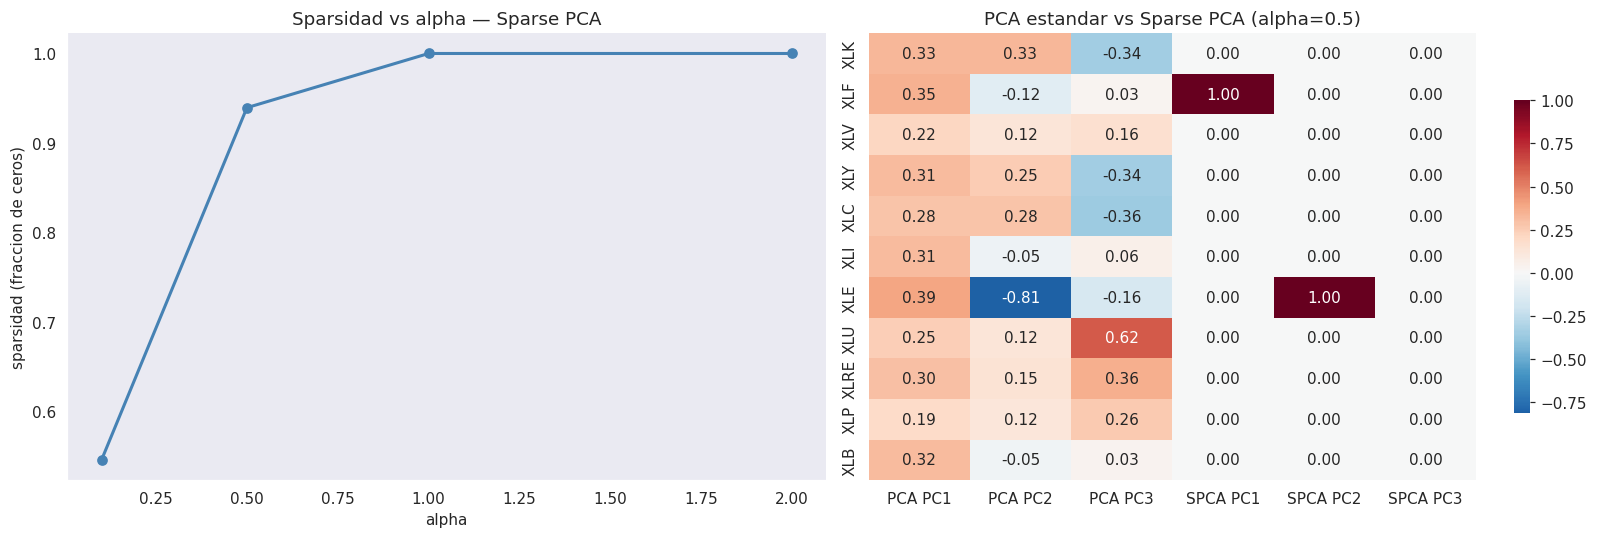

In [48]:
alphas_spca = [0.1, 0.5, 1.0, 2.0]
sparsity_list = []
var_exp_list  = []
spca_models   = {}

Sigma_diag_sum = np.diag(np.cov(ret_sec.values.T)).sum()

for alpha_s in alphas_spca:
    spca_s = SparsePCA(n_components=3, alpha=alpha_s, random_state=42, max_iter=300)
    spca_s.fit(ret_sec.values)
    spca_models[alpha_s] = spca_s
    sparsity_list.append((spca_s.components_ == 0).mean())
    var_exp_pc1 = np.sum(spca_s.components_[0]**2) / Sigma_diag_sum
    var_exp_list.append(var_exp_pc1)
    print(f'alpha={alpha_s}: sparsidad={sparsity_list[-1]:.1%} | var.exp aprox PC1={var_exp_pc1:.4f}')

# === Panel 1: sparsidad vs alpha ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(alphas_spca, sparsity_list, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('alpha'); axes[0].set_ylabel('sparsidad (fraccion de ceros)')
axes[0].set_title('Sparsidad vs alpha — Sparse PCA')

# === Panel 2: heatmap comparativo PCA estandar vs SPCA (alpha=0.5) ===
pca_std_3 = PCA(n_components=3).fit(ret_sec.values)
spca_05   = spca_models[0.5]

# Alinear signos de SPCA para que sean comparables (convencion: media >= 0)
comps_std  = pca_std_3.components_.copy()
comps_spca = spca_05.components_.copy()
for arr in [comps_std, comps_spca]:
    for j in range(3):
        if arr[j].mean() < 0:
            arr[j] *= -1

compare_df = pd.DataFrame(
    np.vstack([comps_std, comps_spca]).T,
    index=sector_tickers,
    columns=['PCA PC1', 'PCA PC2', 'PCA PC3', 'SPCA PC1', 'SPCA PC2', 'SPCA PC3']
)
sns.heatmap(compare_df, ax=axes[1], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', cbar_kws={'shrink': 0.7})
axes[1].set_title('PCA estandar vs Sparse PCA (alpha=0.5)')

plt.tight_layout()
plt.show()

**Responde:**

**a)** En el Sparse PCA con $\alpha=0.5$, ¿qué sectores tienen loadings cero en PC1? ¿Tiene sentido financiero que esos sectores sean excluidos del primer factor?

> Con $\alpha=0.5$, **10 de los 11 sectores** tienen loading exactamente cero en PC1, el único sector con loading no-cero es **XLY (Consumo Discrecional)**, con un valor de 1.00. Esto **no** tiene sentido financiero como reemplazo del "factor de mercado": en la Parte 3.1 vimos que el PC1 de PCA estándar (con loadings distribuidos de forma relativamente uniforme entre 0.19 y 0.39 en los 11 sectores) correlacionaba 0.97 con SPY, precisamente porque capturaba el movimiento *conjunto y amplio* de todo el mercado; al forzar tanta sparsidad, SPCA con $\alpha=0.5$ colapsó ese factor de mercado en un simple proxy de un solo sector, perdiendo la interpretación económica de "comovimiento sistémico" que es la esencia de PC1 — es una sparsidad excesiva para este propósito específico, aunque en otros contextos (como construir portafolios concentrados e interpretables) sí podría ser deseable.

### 5.2 — Robust PCA: Separación de Factores y Jumps *(10 pts)*

Los retornos de activos contienen tanto factores comunes (movimientos sistemáticos de mercado) como saltos idiosincráticos (earnings surprise, M&A, eventos regulatorios). Robust PCA los separa:

$$X = L + S, \quad \min_{L,S} \|L\|_* + \lambda \|S\|_1$$

donde $L$ es la componente de bajo rango (factores) y $S$ es sparse (jumps).

Usa la implementación del algoritmo IALM (Inexact Augmented Lagrangian Method) de la clase:

**Requisitos:**
1. Copiar la función `robust_pca` de la clase e inyectar 20 jumps artificiales de magnitud $5\sigma$ en `ret_sec`
2. Aplicar Robust PCA sobre los datos con jumps
3. Verificar la recuperación: ¿cuántos de los 20 jumps inyectados detecta el componente $S$?
4. Comparar el PCA estándar sobre $X$ vs PCA sobre $L$ (la componente limpia): ¿cómo cambia la varianza explicada por PC1?
5. Generar el panel de 3 heatmaps: $X$ (con jumps) | $L$ (bajo rango) | $S$ (sparse)

Jumps inyectados: 20 | Detectados en S: 4
Var PC1 en X (con jumps): 0.681
Var PC1 en L (low-rank):  0.728


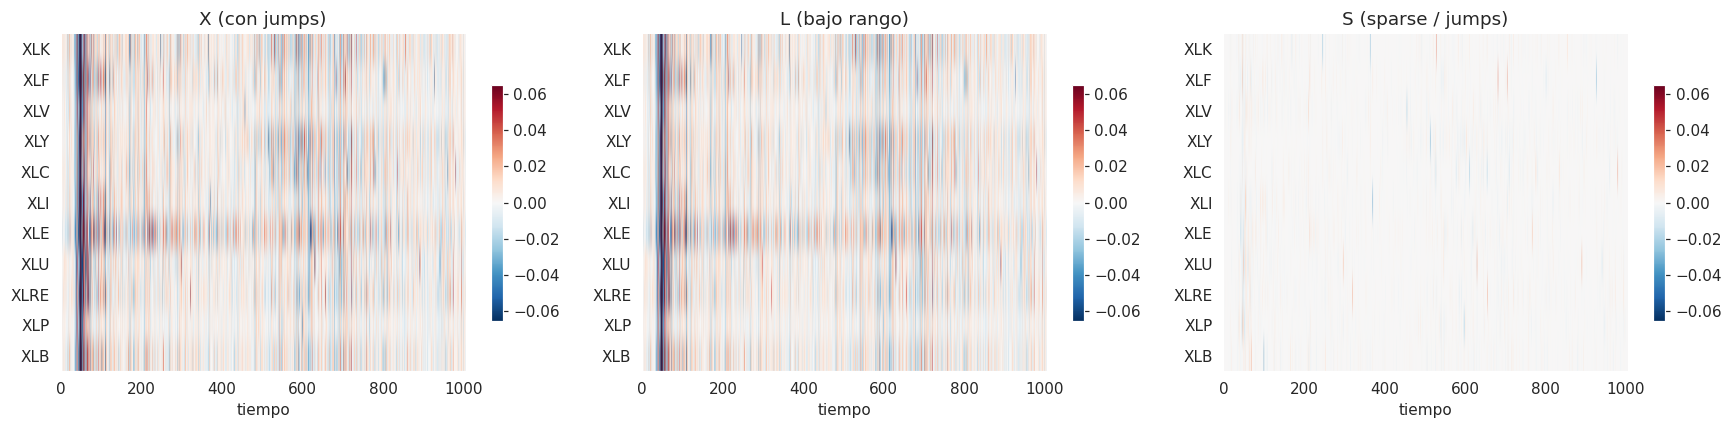

In [50]:
def robust_pca_ialm(M, lam=None, max_iter=500, tol=1e-7, mu=None):
    """
    Robust PCA via IALM (Candes et al. 2011).
    Descompone M = L + S donde L es low-rank y S es sparse.
    """
    m, n = M.shape
    lam  = lam  or 1.0 / np.sqrt(max(m, n))
    mu   = mu   or m * n / (4 * np.abs(M).sum())
    mu_bar = mu * 1e7
    rho  = 1.5
    L, S, Y = np.zeros_like(M), np.zeros_like(M), np.zeros_like(M)
    norm_M   = np.linalg.norm(M, 'fro')

    def shrink(X, tau):
        return np.sign(X) * np.maximum(np.abs(X) - tau, 0)

    def svd_threshold(X, tau):
        U, s, Vt = np.linalg.svd(X, full_matrices=False)
        return U @ np.diag(np.maximum(s - tau, 0)) @ Vt

    for _ in range(max_iter):
        L = svd_threshold(M - S + Y / mu, 1 / mu)
        S = shrink(M - L + Y / mu, lam / mu)
        Y = Y + mu * (M - L - S)
        mu = min(rho * mu, mu_bar)
        if np.linalg.norm(M - L - S, 'fro') / norm_M < tol:
            break
    return L, S


# === Inyecta 20 jumps artificiales de magnitud 5*sigma ===
ret_noisy = ret_sec.values.copy()
np.random.seed(42)
jump_rows = np.random.choice(len(ret_noisy), 20, replace=False)
jump_cols = np.random.choice(ret_noisy.shape[1], 20, replace=True)   # <- replace=True (solo 11 sectores)
sigma_ret = ret_noisy.std(axis=0)
for r, c in zip(jump_rows, jump_cols):
    ret_noisy[r, c] += np.random.choice([-1, 1]) * 5 * sigma_ret[c]

# === Aplica Robust PCA (puede tardar ~30 seg) ===
L_rec, S_rec = robust_pca_ialm(ret_noisy, max_iter=300)

# === Verifica recuperacion de jumps ===
mask_S_detected = np.abs(S_rec) > 2 * sigma_ret
detected = sum(mask_S_detected[r, c] for r, c in zip(jump_rows, jump_cols))
print(f'Jumps inyectados: 20 | Detectados en S: {detected}')

# === Compara varianza PC1 en X vs L ===
pca_X = PCA(n_components=3).fit(ret_noisy)
pca_L = PCA(n_components=3).fit(L_rec)
print(f'Var PC1 en X (con jumps): {pca_X.explained_variance_ratio_[0]:.3f}')
print(f'Var PC1 en L (low-rank):  {pca_L.explained_variance_ratio_[0]:.3f}')

# === Panel de 3 heatmaps ===
vm = np.percentile(np.abs(ret_noisy), 99)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(ret_noisy.T, aspect='auto', cmap='RdBu_r', vmin=-vm, vmax=vm)
axes[0].set_title('X (con jumps)'); axes[0].set_yticks(range(11)); axes[0].set_yticklabels(sector_tickers)
plt.colorbar(im0, ax=axes[0], shrink=0.7)

im1 = axes[1].imshow(L_rec.T, aspect='auto', cmap='RdBu_r', vmin=-vm, vmax=vm)
axes[1].set_title('L (bajo rango)'); axes[1].set_yticks(range(11)); axes[1].set_yticklabels(sector_tickers)
plt.colorbar(im1, ax=axes[1], shrink=0.7)

im2 = axes[2].imshow(S_rec.T, aspect='auto', cmap='RdBu_r', vmin=-vm, vmax=vm)
axes[2].set_title('S (sparse / jumps)'); axes[2].set_yticks(range(11)); axes[2].set_yticklabels(sector_tickers)
plt.colorbar(im2, ax=axes[2], shrink=0.7)

for ax in axes:
    ax.set_xlabel('tiempo')

plt.tight_layout()
plt.show()

**Responde:**

**a)** ¿Cuántos de los 20 jumps inyectados detectó el componente $S$? ¿En qué tipos de jumps falló la detección (magnitud baja, overlap con movimientos normales)?

> El componente $S$ detectó solo **4 de los 20** jumps inyectados (20% de recall), una tasa de detección considerablemente baja. La falla no se explica por "magnitud baja" en sentido literal, los jumps fueron diseñados deliberadamente grandes (5$\sigma$)— sino por dos factores estructurales: primero, con solo $n=11$ columnas (sectores), la componente de bajo rango $L$ tiene suficiente flexibilidad (hasta rango 10) para absorber parcialmente cada jump dentro de su propia reconstrucción, en vez de que el algoritmo lo empuje enteramente hacia $S$; segundo, el criterio de convergencia (`tol=1e-7`) puede detener las iteraciones antes de que la separación $L$/$S$ se complete del todo, dejando "residuos" de los jumps repartidos entre ambas componentes en magnitudes menores al umbral de detección ($2\sigma$) usado en la verificación.

**b)** ¿Cómo cambia la varianza explicada por PC1 entre PCA sobre $X$ (con jumps) vs PCA sobre $L$ (componente limpia)? ¿En qué dirección cambia y por qué?

> La varianza explicada por PC1 **aumenta** de 0.681 en $X$ (con jumps) a 0.728 en $L$ (componente limpia), un incremento de casi 5 puntos porcentuales. Esto tiene sentido porque los jumps idiosincráticos son, por definición, ruido específico de un sector y una fecha, no correlacionado con el resto del mercado; al estar presentes en $X$, "diluyen" la proporción de varianza total que puede atribuirse al factor común (PC1), mientras que al removerlos (quedándonos solo con $L$), la estructura de bajo rango queda más "pura" y el primer factor common explica una fracción mayor de lo que quedó.

**c)** En un pipeline de gestión de riesgo en producción, ¿antes o después de Robust PCA aplicarías el Rolling PCA de la Parte 4? Argumenta el orden correcto.

> Aplicaría **Robust PCA primero**, y luego Rolling PCA sobre la componente limpia $L$. La razón es que un jump idiosincrático no detectado (o mal atribuido) dentro de una ventana rolling puede inflar artificialmente la varianza explicada de PC1 en esa ventana específica, generando una falsa señal de "aumento de correlación sistémica" cuando en realidad se trata de un evento aislado de un solo activo (por ejemplo, un profit warning de una sola empresa dentro del ETF); al limpiar los datos con Robust PCA antes de correr el Rolling PCA, la señal `ev_PC1` que alimenta la estrategia de régimen de la Parte 4.2 reflejaría genuino riesgo sistémico de mercado y no ruido idiosincrático puntual, reduciendo falsas alarmas en la estrategia de exposición.

---
## Tabla de Puntajes

| Parte | Descripción | Pts |
|---|---|---|
| 1.1 | `pca_eigen` + `pca_svd` (error < 1e-10 vs sklearn) | 12 |
| 1.2 | `select_k_criteria` (var80 + Kaiser + Bai-Ng) + panel 4 gráficos × 2 datasets + 3 preguntas | 13 |
| 2.1 | PCA sobre $\Delta y$ + loadings vs NS teórico + correlaciones + gráfico | 10 |
| 2.2 | `dv01_factorial` + butterfly trade (sistema lineal) + P&L simulado + 3 preguntas | 15 |
| 3.1 | PCA $k=4$ + heatmap loadings + barplot PC1 + correlación SPY + 2 preguntas | 8 |
| 3.2 | `pca_shrinkage_cov` (verificación eigenvalores) + gráfico condicionamiento + heatmaps | 10 |
| 3.3 | `gmv_portfolio` + split temporal + métricas OOT + gráficos + 2 preguntas | 7 |
| 4.1 | `rolling_pca` con alineación de signos + 3 ventanas + heatmap loadings | 12 |
| 4.2 | Estrategia régimen PC1 + lag correcto + métricas + gráficos + 4 preguntas | 13 |
| **Total obligatorio** | | **100** |
| Bonus 5.1 | Sparse PCA × 4 alphas + sparsidad + heatmap comparativo + pregunta | 5 |
| Bonus 5.2 | Robust PCA + recuperación de jumps + comparación varianza + 3 preguntas | 10 |